In [1]:
import healpy
import healpy as hp
from jax_healpy import pixelfunc as jhp
import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import optax
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import hera_filters as hf
from functools import partial
import scipy
from pathlib import Path
from datetime import datetime, timezone
from scipy.signal.windows import dpss
from scipy.optimize import curve_fit
from scipy.special import sph_harm_y
from scipy.linalg import lstsq
from scipy.optimize import minimize_scalar
from scipy.optimize import differential_evolution, minimize
from scipy.optimize import least_squares
from scipy.ndimage import median_filter
from scipy.ndimage import binary_dilation

import numpy as np
from eigsep_observing.io import read_hdf5
jax.config.update("jax_enable_x64", True)
%matplotlib widget


dtype_r = jnp.float64
DEFAULT_NSIDE = 32
DEFAULT_NPIX = healpy.nside2npix(DEFAULT_NSIDE)
px = jnp.arange(DEFAULT_NPIX)
th, phi = healpy.pix2ang(DEFAULT_NSIDE, px)
DEFAULT_BEAM_TH = jnp.cos(th)**2 * jnp.cos(phi)**2
DEFAULT_BEAM_PHI = jnp.cos(th)**2 * jnp.sin(phi)**2
save_path = '/Users/dominiv/sfsu/thesis/figures/'
path = '/Users/dominiv/research/data/deployment5_filtered/'
data_dir = Path(path)

# start_time = "2026-7-17 6:00:00"
# end_time   = "2026-7-17 8:00:00"
start_time = "2026-07-17 20:26:00"
end_time   = "2026-07-17 21:28:00"

# Search for both common HDF5 extensions.
file_patterns = ["*.h5", "*.hdf5"]

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


## Functions

In [2]:
def to_unix_time(value):
    """
    Convert a datetime string, datetime object, or Unix timestamp
    into Unix seconds.

    Strings without a timezone are interpreted as UTC.

    Accepted examples:
        "2026-07-17 06:00:00"
        "2026-7-17 6:00:00"
        "2026-07-17T06:00:00Z"
    """
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    if isinstance(value, datetime):
        dt = value

    else:
        text = str(value).strip()

        # Try standard ISO parsing first.
        try:
            dt = datetime.fromisoformat(
                text.replace("Z", "+00:00")
            )

        except ValueError:
            # Allow dates and times without zero padding.
            accepted_formats = [
                "%Y-%m-%d %H:%M:%S",
                "%Y-%m-%d %H:%M",
                "%Y-%m-%d",
            ]

            for date_format in accepted_formats:
                try:
                    dt = datetime.strptime(text, date_format)
                    break
                except ValueError:
                    continue

            else:
                raise ValueError(
                    f"Could not interpret time {value!r}. "
                    "Use a format such as '2026-07-17 06:00:00'."
                )

    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)

    return dt.timestamp()


# ============================================================
# Find files and convert requested times
# ============================================================



In [3]:


# # ============================================================
# # Basic normalization helper
# # ============================================================

# def normalize_each_freq(x, valid=None, eps=1e-30):
#     """
#     Normalize each frequency column by its valid mean.

#     x shape:
#         (ntime, nfreq)
#     """
#     x = np.asarray(x, dtype=float)
#     out = np.full_like(x, np.nan, dtype=float)

#     if valid is None:
#         valid = np.isfinite(x)
#     else:
#         valid = np.asarray(valid).astype(bool) & np.isfinite(x)

#     for fi in range(x.shape[1]):
#         good = valid[:, fi]
#         if np.sum(good) > 0:
#             m = np.nanmean(x[good, fi])
#             if np.isfinite(m) and np.abs(m) > eps:
#                 out[good, fi] = x[good, fi] / m

#     return out


# # ============================================================
# # DPSS basis and per-time fitting
# # ============================================================

# def build_dpss_basis(
#     nchan,
#     nw=4.0,
#     nterms=16,
#     include_poly=True,
#     poly_order=2,
# ):
#     """
#     Build a smooth spectral basis using DPSS tapers plus optional polynomials.

#     nchan:
#         Number of raw spectral channels.

#     nw:
#         DPSS time-bandwidth product. Larger means more spectral flexibility.

#     nterms:
#         Number of DPSS basis vectors.

#     include_poly:
#         Add low-order polynomial basis vectors.

#     poly_order:
#         Highest polynomial order to include.
#     """
#     basis = []

#     tapers = dpss(M=nchan, NW=nw, Kmax=nterms, sym=False)
#     for k in range(tapers.shape[0]):
#         basis.append(tapers[k])

#     if include_poly:
#         x = np.linspace(-1, 1, nchan)
#         for p in range(poly_order + 1):
#             basis.append(x ** p)

#     A = np.vstack(basis).T

#     # Normalize columns for numerical stability.
#     A = A / np.maximum(np.linalg.norm(A, axis=0, keepdims=True), 1e-30)

#     return A


# def make_dpss_fit_mask(
#     nchan,
#     chs,
#     guard_bins=1,
#     fit_min_chan=None,
#     fit_max_chan=None,
# ):
#     """
#     Make mask of raw spectral channels used in DPSS fit.

#     Excludes:
#       - transmitted comb channels chs
#       - guard bins around each comb channel
#       - channels outside [fit_min_chan, fit_max_chan)
#     """
#     chs = np.asarray(chs).astype(int)

#     if fit_min_chan is None:
#         fit_min_chan = 0
#     if fit_max_chan is None:
#         fit_max_chan = nchan

#     fit_min_chan = max(0, int(fit_min_chan))
#     fit_max_chan = min(nchan, int(fit_max_chan))

#     fit_mask = np.zeros(nchan, dtype=bool)
#     fit_mask[fit_min_chan:fit_max_chan] = True

#     for c in chs:
#         lo = max(0, c - guard_bins)
#         hi = min(nchan, c + guard_bins + 1)
#         fit_mask[lo:hi] = False

#     return fit_mask


# def fit_smooth_model_one_spectrum(
#     spectrum,
#     basis,
#     fit_mask,
#     use_log=True,
#     ridge=1e-6,
#     min_good_extra=2,
# ):
#     """
#     Fit one smooth DPSS model to a single spectrum.

#     Returns a model in raw power units.
#     """
#     y = np.asarray(spectrum, dtype=float)
#     nchan, nbasis = basis.shape

#     good = fit_mask & np.isfinite(y)

#     if use_log:
#         good &= y > 0

#     if np.sum(good) < nbasis + min_good_extra:
#         return np.full(nchan, np.nan, dtype=float)

#     Ag = basis[good]

#     if use_log:
#         yy = np.log(np.maximum(y[good], 1e-30))
#     else:
#         yy = y[good]

#     lhs = Ag.T @ Ag + ridge * np.eye(nbasis)
#     rhs = Ag.T @ yy
#     coeff = np.linalg.solve(lhs, rhs)

#     model_fit = basis @ coeff

#     if use_log:
#         model_fit = np.exp(model_fit)

#     return model_fit


# def fit_dpss_model_per_time(
#     raw,
#     chs,
#     nw=4.0,
#     nterms=16,
#     include_poly=True,
#     poly_order=2,
#     guard_bins=1,
#     fit_min_chan=None,
#     fit_max_chan=None,
#     use_log=True,
#     ridge=1e-6,
#     verbose=True,
# ):
#     """
#     Fit an independent smooth DPSS model to every time sample.

#     Parameters
#     ----------
#     raw:
#         Raw spectra, shape (ntime, nraw_channels).

#     chs:
#         Raw channel indices of transmitted comb tones. These are excluded
#         from the smooth fit and then evaluated as:
#             reduced = raw[:, chs] - model[:, chs]

#     Returns
#     -------
#     dict:
#         model_raw:
#             Smooth model in raw power units, shape (ntime, nraw_channels)

#         reduced:
#             Comb-channel reduced data, shape (ntime, nfreq)

#         test_data:
#             Per-frequency normalized reduced data, shape (ntime, nfreq)

#         fit_mask:
#             Boolean mask over raw channels used for the smooth fit.

#         basis:
#             DPSS/polynomial basis matrix.
#     """
#     raw = np.asarray(raw, dtype=float)
#     chs = np.asarray(chs).astype(int)

#     ntime, nchan = raw.shape

#     if np.any(chs < 0) or np.any(chs >= nchan):
#         raise ValueError("Some entries of chs are outside the raw spectral axis.")

#     basis = build_dpss_basis(
#         nchan=nchan,
#         nw=nw,
#         nterms=nterms,
#         include_poly=include_poly,
#         poly_order=poly_order,
#     )

#     fit_mask = make_dpss_fit_mask(
#         nchan=nchan,
#         chs=chs,
#         guard_bins=guard_bins,
#         fit_min_chan=fit_min_chan,
#         fit_max_chan=fit_max_chan,
#     )

#     if verbose:
#         print("raw shape:", raw.shape)
#         print("number of comb channels:", len(chs))
#         print("number of fit channels:", np.sum(fit_mask))
#         print("basis shape:", basis.shape)
#         print("use_log:", use_log)

#     model_raw = np.full_like(raw, np.nan, dtype=float)

#     for ti in range(ntime):
#         model_raw[ti] = fit_smooth_model_one_spectrum(
#             spectrum=raw[ti],
#             basis=basis,
#             fit_mask=fit_mask,
#             use_log=use_log,
#             ridge=ridge,
#         )

#         if verbose and (ti % 500 == 0):
#             print(f"fit {ti}/{ntime}")

#     reduced = raw[:, chs] - model_raw[:, chs]

#     test_data_dpss = normalize_each_freq(
#         reduced,
#         valid=np.isfinite(reduced) & (reduced > 0),
#     )

#     return {
#         "model_raw": model_raw,
#         "reduced": reduced,
#         "test_data": test_data_dpss,
#         "fit_mask": fit_mask,
#         "basis": basis,
#         "chs": chs,
#         "nw": nw,
#         "nterms": nterms,
#         "include_poly": include_poly,
#         "poly_order": poly_order,
#         "guard_bins": guard_bins,
#         "fit_min_chan": fit_min_chan,
#         "fit_max_chan": fit_max_chan,
#         "use_log": use_log,
#         "ridge": ridge,
#     }

# def fit_dpss_interleaved(P_meas, nmodes=20, NW=4.0):
#     """
#     P_meas : array, shape (nfreq, nsample)
#         Interleaved power measurements.
#         Even frequencies are x-pol, odd frequencies are y-pol.

#     Returns
#     -------
#     Px_hat : shape (nfreq, nsample)
#         DPSS model for x-pol power on full frequency grid.

#     Py_hat : shape (nfreq, nsample)
#         DPSS model for y-pol power on full frequency grid.

#     G_hat : shape (nfreq, nsample)
#         Estimated total power gain Px_hat + Py_hat.
#     """

#     P_meas = np.asarray(P_meas, dtype=float)

#     nfreq, nsample = P_meas.shape

#     # DPSS basis over frequency axis
#     B = dpss(nfreq, NW=NW, Kmax=nmodes).T
#     # B shape: (nfreq, nmodes)

#     x_mask = np.zeros(nfreq, dtype=bool)
#     y_mask = np.zeros(nfreq, dtype=bool)

#     x_mask[::2] = True
#     y_mask[1::2] = True

#     # Observed data for each polarization
#     Yx_obs = P_meas[x_mask, :]   # shape (n_xfreq, nsample)
#     Yy_obs = P_meas[y_mask, :]   # shape (n_yfreq, nsample)

#     Bx = B[x_mask, :]            # shape (n_xfreq, nmodes)
#     By = B[y_mask, :]            # shape (n_yfreq, nmodes)

#     # Solve Bx @ Cx = Yx_obs for all samples at once
#     Cx, *_ = np.linalg.lstsq(Bx, Yx_obs, rcond=None)
#     Cy, *_ = np.linalg.lstsq(By, Yy_obs, rcond=None)

#     # Evaluate on full frequency grid
#     Px_hat = B @ Cx              # shape (nfreq, nsample)
#     Py_hat = B @ Cy              # shape (nfreq, nsample)

#     G_hat = Px_hat + Py_hat

#     return Px_hat, Py_hat, G_hat


In [4]:


def build_dpss_basis(
    nchan,
    nw=4.0,
    nterms=16,
    include_poly=True,
    poly_order=2,
):
    """
    Build a smooth spectral basis using DPSS tapers plus optional polynomials.

    nchan:
        Number of raw spectral channels.

    nw:
        DPSS time-bandwidth product. Larger means more spectral flexibility.

    nterms:
        Number of DPSS basis vectors.

    include_poly:
        Add low-order polynomial basis vectors.

    poly_order:
        Highest polynomial order to include.
    """
    basis = []

    tapers = dpss(M=nchan, NW=nw, Kmax=nterms, sym=False)
    for k in range(tapers.shape[0]):
        basis.append(tapers[k])

    if include_poly:
        x = np.linspace(-1, 1, nchan)
        for p in range(poly_order + 1):
            basis.append(x ** p)

    A = np.vstack(basis).T

    # Normalize columns for numerical stability.
    A = A / np.maximum(np.linalg.norm(A, axis=0, keepdims=True), 1e-30)

    return A


def normalize_each_freq(x, valid=None, eps=1e-30):
    """
    Normalize each frequency column by its valid mean.

    x shape:
        (ntime, nfreq)
    """
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    if valid is None:
        valid = np.isfinite(x)
    else:
        valid = np.asarray(valid).astype(bool) & np.isfinite(x)

    for fi in range(x.shape[1]):
        good = valid[:, fi]
        if np.sum(good) > 0:
            m = np.nanmean(x[good, fi])
            if np.isfinite(m) and np.abs(m) > eps:
                out[good, fi] = x[good, fi] / m

    return out


def build_frequency_trust_mask(
    freqs,
    min_freq=50.0,
    fm_low=87.0,
    fm_high=108.0,
):
    """
    Return boolean mask selecting trusted frequencies.
    Assumes freqs are in MHz.
    """
    freqs = np.asarray(freqs, dtype=float)
    trusted = np.isfinite(freqs)

    if min_freq is not None:
        trusted &= freqs >= min_freq

    if fm_low is not None and fm_high is not None:
        fm = (freqs >= fm_low) & (freqs <= fm_high)
        trusted &= ~fm

    return trusted

def make_dpss_fit_mask(
    nchan,
    chs,
    guard_bins=1,
    fit_min_chan=None,
    fit_max_chan=None,
    freqs=None,
    min_freq=50.0,
    fm_low=87.0,
    fm_high=108.0,
):
    """
    Make mask of raw spectral channels used in the DPSS fit.
    """
    chs = np.asarray(chs).astype(int)

    if fit_min_chan is None:
        fit_min_chan = 0
    if fit_max_chan is None:
        fit_max_chan = nchan

    fit_min_chan = max(0, int(fit_min_chan))
    fit_max_chan = min(nchan, int(fit_max_chan))

    fit_mask = np.zeros(nchan, dtype=bool)
    fit_mask[fit_min_chan:fit_max_chan] = True

    if freqs is not None:
        freqs = np.asarray(freqs, dtype=float)
        if freqs.shape != (nchan,):
            raise ValueError(f"freqs must have shape ({nchan},), got {freqs.shape}")

        trusted_freq = build_frequency_trust_mask(
            freqs=freqs,
            min_freq=min_freq,
            fm_low=fm_low,
            fm_high=fm_high,
        )
        fit_mask &= trusted_freq

    # Remove comb channels and guard bins
    for c in chs:
        lo = max(0, c - guard_bins)
        hi = min(nchan, c + guard_bins + 1)
        fit_mask[lo:hi] = False

    return fit_mask

def fit_smooth_model_one_spectrum(
    spectrum,
    basis,
    fit_mask,
    constraint_chs=None,
    use_log=True,
    ridge=1e-6,
    min_good_extra=2,
    enforce_comb_upper=True,
    maxiter=300,
    ftol=1e-10,
    constraint_tol=1e-8,
    return_info=False,
):
    """
    Fit one smooth DPSS bandpass model with robust RFI rejection (IRLS).
    """
    y = np.asarray(spectrum, dtype=float)
    nchan, nbasis = basis.shape

    good = fit_mask & np.isfinite(y)

    if use_log:
        good &= y > 0

    if np.sum(good) < nbasis + min_good_extra:
        model = np.full(nchan, np.nan)
        info = {
            "success": False,
            "message": "Not enough valid fit channels",
            "constraint_active": False,
            "max_constraint_violation": np.nan,
        }
        return (model, info) if return_info else model

    Ag = basis[good]

    # --- FIX 1: LOG FLOOR TO PREVENT DEEP NULL TRAP ---
    if use_log:
        floor_val = np.percentile(y[good], 1) # Prevent log(1e-12) dragging the fit
        yy = np.log(np.clip(y[good], floor_val, None))
    else:
        yy = y[good]

    # --- FIX 2: ROBUST FITTING (IRLS) TO IGNORE RFI ---
    # First pass: standard ridge solution
    lhs = Ag.T @ Ag + ridge * np.eye(nbasis)
    rhs = Ag.T @ yy
    try:
        coeff0 = np.linalg.solve(lhs, rhs)
    except np.linalg.LinAlgError:
        coeff0 = np.linalg.lstsq(lhs, rhs, rcond=None)[0]

    # Find outliers (RFI) using Median Absolute Deviation (MAD)
    residuals = yy - (Ag @ coeff0)
    med_res = np.median(residuals)
    mad = np.median(np.abs(residuals - med_res))
    std_robust = 1.4826 * mad
    
    # We only care about large POSITIVE residuals (RFI adds power)
    rfi_mask = residuals > (med_res + 3.0 * (std_robust + 1e-8))

    # Second pass: Refit completely ignoring the RFI spikes
    Ag_fit = Ag[~rfi_mask]
    yy_fit = yy[~rfi_mask]
    
    lhs_clean = Ag_fit.T @ Ag_fit + ridge * np.eye(nbasis)
    rhs_clean = Ag_fit.T @ yy_fit
    
    try:
        coeff0 = np.linalg.solve(lhs_clean, rhs_clean)
    except np.linalg.LinAlgError:
        coeff0 = np.linalg.lstsq(lhs_clean, rhs_clean, rcond=None)[0]

    # ----------------------------------------------------------
    # No constraints requested
    # ----------------------------------------------------------
    if (not enforce_comb_upper or constraint_chs is None or len(constraint_chs) == 0):
        coeff = coeff0
        model_fit = basis @ coeff
        if use_log:
            model_fit = np.exp(model_fit)
        info = {
            "success": True,
            "message": "Unconstrained ridge fit",
            "constraint_active": False,
            "max_constraint_violation": 0.0,
        }
        return (model_fit, info) if return_info else model_fit

    # ----------------------------------------------------------
    # Valid comb-channel constraints
    # ----------------------------------------------------------
    constraint_chs = np.asarray(constraint_chs, dtype=int)
    yc = y[constraint_chs]
    constraint_good = np.isfinite(yc)

    if use_log:
        constraint_good &= yc > 0

    constraint_chs_good = constraint_chs[constraint_good]

    if len(constraint_chs_good) == 0:
        coeff = coeff0
        model_fit = basis @ coeff
        if use_log:
            model_fit = np.exp(model_fit)
        info = {
            "success": True,
            "message": "No valid constraint channels",
            "constraint_active": False,
            "max_constraint_violation": np.nan,
        }
        return (model_fit, info) if return_info else model_fit

    Ac = basis[constraint_chs_good]

    if use_log:
        upper = np.log(y[constraint_chs_good])
    else:
        upper = y[constraint_chs_good]

    initial_violation = np.max(Ac @ coeff0 - upper)

    if initial_violation <= constraint_tol:
        coeff = coeff0
        model_fit = basis @ coeff
        if use_log:
            model_fit = np.exp(model_fit)
        info = {
            "success": True,
            "message": "Unconstrained solution already feasible",
            "constraint_active": False,
            "max_constraint_violation": max(0.0, float(initial_violation)),
        }
        return (model_fit, info) if return_info else model_fit

    # ----------------------------------------------------------
    # Constrained ridge objective (using the RFI-cleaned data!)
    # ----------------------------------------------------------
    def objective(coeff):
        residual = Ag_fit @ coeff - yy_fit
        return 0.5 * np.dot(residual, residual) + 0.5 * ridge * np.dot(coeff, coeff)

    def gradient(coeff):
        return Ag_fit.T @ (Ag_fit @ coeff - yy_fit) + ridge * coeff

    constraints = {
        "type": "ineq",
        "fun": lambda coeff: upper - Ac @ coeff,
        "jac": lambda coeff: -Ac,
    }

    result = minimize(
        objective,
        coeff0,
        jac=gradient,
        constraints=constraints,
        method="SLSQP",
        options={"maxiter": maxiter, "ftol": ftol, "disp": False},
    )

    coeff = result.x
    violation = np.max(Ac @ coeff - upper)
    max_violation = max(0.0, float(violation))
    success = result.success and max_violation <= constraint_tol

    if not success:
        model_fit = np.full(nchan, np.nan)
        info = {
            "success": False,
            "message": result.message,
            "constraint_active": True,
            "max_constraint_violation": max_violation,
        }
        return (model_fit, info) if return_info else model_fit

    model_fit = basis @ coeff

    if use_log:
        model_fit = np.exp(model_fit)

    info = {
        "success": True,
        "message": result.message,
        "constraint_active": True,
        "max_constraint_violation": max_violation,
    }

    return (model_fit, info) if return_info else model_fit


def fit_dpss_model_per_time(
    raw,
    chs,
    freqs,
    nw=4.0,
    nterms=8,
    include_poly=True,
    poly_order=2,
    guard_bins=1,
    fit_min_chan=None,
    fit_max_chan=None,
    min_freq=50.0,
    fm_low=87.0,
    fm_high=108.0,
    use_log=True,
    ridge=1e-6,
    enforce_comb_upper=True,
    mask_untrusted_output=True,
    constraint_tol=1e-8,
    optimizer_maxiter=300,
    optimizer_ftol=1e-10,
    verbose=True,
):
    """
    Fit smooth DPSS bandpass independently at each time.
    """
    raw = np.asarray(raw, dtype=float)
    chs = np.asarray(chs).astype(int)
    freqs = np.asarray(freqs, dtype=float)

    ntime, nchan = raw.shape

    if freqs.shape != (nchan,):
        raise ValueError(f"freqs must have shape ({nchan},), got {freqs.shape}")

    if np.any(chs < 0) or np.any(chs >= nchan):
        raise ValueError("Some entries of chs are outside the raw spectral axis.")

    trusted_freq_mask = build_frequency_trust_mask(
        freqs=freqs,
        min_freq=min_freq,
        fm_low=fm_low,
        fm_high=fm_high,
    )

    trusted_comb_mask = trusted_freq_mask[chs]
    trusted_constraint_chs = chs[trusted_comb_mask]

    # Note: Assumes `build_dpss_basis` is defined elsewhere in your environment
    basis = build_dpss_basis(
        nchan=nchan,
        nw=nw,
        nterms=nterms,
        include_poly=include_poly,
        poly_order=poly_order,
    )

    fit_mask = make_dpss_fit_mask(
        nchan=nchan,
        chs=chs,
        guard_bins=guard_bins,
        fit_min_chan=fit_min_chan,
        fit_max_chan=fit_max_chan,
        freqs=freqs,
        min_freq=min_freq,
        fm_low=fm_low,
        fm_high=fm_high,
    )

    if verbose:
        print("number of fit channels:", np.sum(fit_mask))

    model_raw = np.full_like(raw, np.nan, dtype=float)
    fit_success = np.zeros(ntime, dtype=bool)
    constraint_active = np.zeros(ntime, dtype=bool)
    max_constraint_violation = np.full(ntime, np.nan, dtype=float)

    for ti in range(ntime):
        model_t, info = fit_smooth_model_one_spectrum(
            spectrum=raw[ti],
            basis=basis,
            fit_mask=fit_mask,
            constraint_chs=trusted_constraint_chs,
            use_log=use_log,
            ridge=ridge,
            enforce_comb_upper=enforce_comb_upper,
            maxiter=optimizer_maxiter,
            ftol=optimizer_ftol,
            constraint_tol=constraint_tol,
            return_info=True,
        )

        model_raw[ti] = model_t
        fit_success[ti] = info["success"]
        constraint_active[ti] = info["constraint_active"]
        max_constraint_violation[ti] = info["max_constraint_violation"]

        if verbose and ti % 500 == 0:
            print(f"fit {ti}/{ntime} (success={fit_success[ti]}, constraint={constraint_active[ti]})")

    reduced = raw[:, chs] - model_raw[:, chs]

    if mask_untrusted_output:
        reduced[:, ~trusted_comb_mask] = np.nan

    # Note: Assumes `normalize_each_freq` is defined elsewhere in your environment
    test_data_dpss = normalize_each_freq(
        reduced,
        valid=(np.isfinite(reduced) & (reduced >= 0)),
    )

    if verbose:
        print("\nDPSS fit diagnostics")
        print("--------------------")
        print("successful fits:", f"{np.sum(fit_success)}/{ntime}")
        print("fraction successful:", np.mean(fit_success))

    return {
        "model_raw": model_raw,
        "reduced": reduced,
        "test_data": test_data_dpss,
        "fit_mask": fit_mask,
        "trusted_freq_mask": trusted_freq_mask,
        "trusted_comb_mask": trusted_comb_mask,
        "trusted_constraint_chs": trusted_constraint_chs,
        "basis": basis,
        "chs": chs,
        "freqs": freqs,
        "fit_success": fit_success,
    }

def plot_dpss_fit_examples(
    raw,
    dpss_out,
    times_to_plot=(0, 1000, 2000, 3000, 4000),
    yscale="linear",
):
    """
    Plot raw spectrum, DPSS model, comb channels, and fit channels.
    """
    raw = np.asarray(raw)
    model = dpss_out["model_raw"]
    fit_mask = dpss_out["fit_mask"]
    chs = dpss_out["chs"]

    for ti in times_to_plot:
        if ti < 0 or ti >= raw.shape[0]:
            continue

        plt.figure(figsize=(10, 4))
        plt.plot(raw[ti], ".", markersize=3, label="raw spectrum")
        plt.plot(model[ti], "-", linewidth=2, label="per-time DPSS model")
        plt.plot(chs, raw[ti, chs], "o", label="comb channels")
        plt.plot(
            np.where(fit_mask)[0],
            raw[ti, fit_mask],
            ".",
            markersize=2,
            alpha=0.35,
            label="fit channels",
        )

        plt.xlabel("raw channel")
        plt.ylabel("power")
        plt.yscale(yscale)
        plt.title(f"Per-time DPSS fit, time index {ti}")
        plt.grid(True)
        plt.legend()


def plot_dpss_reduced_waterfalls(
    dpss_out,
    test_data_skyavg=None,
    rfi_bad=None,
    diff_lim=0.5,
):
    """
    Plot per-time DPSS reduced normalized waterfall and optionally compare
    to original sky-average normalized waterfall.
    """
    test_data_dpss = np.asarray(dpss_out["test_data"], dtype=float)

    plot_dpss = test_data_dpss.copy()

    if rfi_bad is not None:
        for fi in set(rfi_bad):
            if 0 <= fi < plot_dpss.shape[1]:
                plot_dpss[:, fi] = np.nan

    plt.figure(figsize=(10, 5))
    plt.imshow(
        plot_dpss.T,
        aspect="auto",
        origin="lower",
        interpolation="none",
    )
    plt.colorbar(label="normalized DPSS-reduced data")
    plt.xlabel("time index")
    plt.ylabel("frequency index")
    plt.title("Per-time DPSS reduced data")

    if test_data_skyavg is None:
        return

    test_data_skyavg = np.asarray(test_data_skyavg, dtype=float)

    ntime = min(test_data_skyavg.shape[0], test_data_dpss.shape[0])
    nfreq = min(test_data_skyavg.shape[1], test_data_dpss.shape[1])

    sky = test_data_skyavg[:ntime, :nfreq].copy()
    dps = test_data_dpss[:ntime, :nfreq].copy()

    valid = np.isfinite(sky) & np.isfinite(dps)

    if rfi_bad is not None:
        for fi in set(rfi_bad):
            if 0 <= fi < nfreq:
                valid[:, fi] = False

    sky[~valid] = np.nan
    dps[~valid] = np.nan
    diff = dps - sky
    diff[~valid] = np.nan

    plt.figure(figsize=(10, 5))
    plt.imshow(
        sky.T,
        aspect="auto",
        origin="lower",
        interpolation="none",
    )
    plt.colorbar(label="normalized sky-average data")
    plt.xlabel("time index")
    plt.ylabel("frequency index")
    plt.title("Original sky-average reduced data")

    plt.figure(figsize=(10, 5))
    plt.imshow(
        diff.T,
        aspect="auto",
        origin="lower",
        interpolation="none",
        vmin=-diff_lim,
        vmax=diff_lim,
    )
    plt.colorbar(label="DPSS - skyavg")
    plt.xlabel("time index")
    plt.ylabel("frequency index")
    plt.title("Difference: per-time DPSS - sky-average")


def plot_dpss_median_spectra(
    dpss_out,
    test_data_skyavg=None,
    rfi_bad=None,
):
    """
    Compare median normalized spectra.
    """
    test_data_dpss = np.asarray(dpss_out["test_data"], dtype=float).copy()

    if test_data_skyavg is not None:
        test_data_skyavg = np.asarray(test_data_skyavg, dtype=float).copy()

    if rfi_bad is not None:
        for fi in set(rfi_bad):
            if 0 <= fi < test_data_dpss.shape[1]:
                test_data_dpss[:, fi] = np.nan
            if test_data_skyavg is not None and 0 <= fi < test_data_skyavg.shape[1]:
                test_data_skyavg[:, fi] = np.nan

    plt.figure(figsize=(9, 4))

    if test_data_skyavg is not None:
        plt.plot(
            np.nanmedian(test_data_skyavg, axis=0),
            "o-",
            label="sky-average",
        )

    plt.plot(
        np.nanmedian(test_data_dpss, axis=0),
        "o-",
        label="per-time DPSS",
    )

    plt.xlabel("frequency index")
    plt.ylabel("median normalized amplitude")
    plt.title("Median spectra after reduction")
    plt.grid(True)
    plt.legend()


def summarize_dpss_reduction(dpss_out, test_data_skyavg=None, rfi_bad=None):
    """
    Print basic diagnostics for the DPSS reduction.
    """
    reduced = np.asarray(dpss_out["reduced"], dtype=float)
    test_data_dpss = np.asarray(dpss_out["test_data"], dtype=float)

    valid = np.isfinite(reduced)

    if rfi_bad is not None:
        for fi in set(rfi_bad):
            if 0 <= fi < valid.shape[1]:
                valid[:, fi] = False

    neg_frac = np.mean((reduced <= 0) & valid, axis=0)

    print("DPSS reduced shape:", reduced.shape)
    print("DPSS normalized shape:", test_data_dpss.shape)
    print("median negative fraction:", np.nanmedian(neg_frac))
    print("max negative fraction:", np.nanmax(neg_frac))

    if test_data_skyavg is not None:
        sky = np.asarray(test_data_skyavg, dtype=float)
        ntime = min(sky.shape[0], test_data_dpss.shape[0])
        nfreq = min(sky.shape[1], test_data_dpss.shape[1])

        sky = sky[:ntime, :nfreq]
        dps = test_data_dpss[:ntime, :nfreq]

        comp_valid = np.isfinite(sky) & np.isfinite(dps)

        if rfi_bad is not None:
            for fi in set(rfi_bad):
                if 0 <= fi < nfreq:
                    comp_valid[:, fi] = False

        diff = dps - sky
        print("median abs DPSS-skyavg difference:", np.nanmedian(np.abs(diff[comp_valid])))
        print("RMS DPSS-skyavg difference:", np.sqrt(np.nanmean(diff[comp_valid] ** 2)))

    return {
        "neg_frac": neg_frac,
    }

In [5]:

def calibrate_weak_arm(el_deg, az_deg, dpss_red):
    """
    Calculates scale factors to normalize the weak arm tones to the strong arm tones.
    Uses index-based interpolation to guarantee shape matching.
    """
    
    # 1. Find all indices where el_deg crosses 0
    crossings = np.where(np.diff(np.sign(el_deg)))[0]
    valid_crossings = [i for i in crossings if abs(el_deg[i]) < 10]
    
    az_at_0 = []
    power_at_0 = []
    
    # 2. Linearly interpolate power at exactly el = 0
    for i in valid_crossings:
        el0, el1 = el_deg[i], el_deg[i+1]
        az0, az1 = az_deg[i], az_deg[i+1]
        p0, p1 = dpss_red[i], dpss_red[i+1]
        
        t = (0.0 - el0) / (el1 - el0)
        
        az_interp = az0 + t * (az1 - az0)
        az_at_0.append(az_interp)
        
        p_interp = p0 + t * (p1 - p0)
        power_at_0.append(p_interp)
        
    az_at_0 = np.array(az_at_0)
    power_at_0 = np.array(power_at_0) 
    
    def malus_law(az, peak_power, min_power, phase_offset):
        az_rad = np.deg2rad(az)
        phase_rad = np.deg2rad(phase_offset)
        return min_power + (peak_power - min_power) * np.cos(az_rad - phase_rad)**2

    num_freqs = dpss_red.shape[1]
    peak_powers = np.full(num_freqs, np.nan)
    
    # 3. Fit polarization curve
    for f_idx in range(num_freqs):
        p_freq = power_at_0[:, f_idx]
        
        valid_mask = np.isfinite(p_freq) & np.isfinite(az_at_0)
        
        if np.sum(valid_mask) < 4:
            continue
            
        p_valid = p_freq[valid_mask]
        az_valid = az_at_0[valid_mask]
        
        p_max = np.max(p_valid)
        p_min = np.min(p_valid)
        phase_guess = az_valid[np.argmax(p_valid)]
        
        try:
            popt, _ = curve_fit(
                malus_law, 
                az_valid, 
                p_valid, 
                p0=[p_max, p_min, phase_guess]
            )
            peak_powers[f_idx] = popt[0] 
        except RuntimeError:
            peak_powers[f_idx] = p_max

    # 4. Interpolate using array indices instead of physical frequencies
    idx = np.arange(num_freqs)
    
    idx_strong = idx[0::2]
    peaks_strong = peak_powers[0::2]
    
    idx_weak = idx[1::2]
    peaks_weak = peak_powers[1::2]
    
    valid_strong = np.isfinite(peaks_strong)
    
    expected_strong_at_weak = np.full_like(peaks_weak, np.nan)
    
    if np.any(valid_strong):
        # np.interp strictly requires the x-coordinates to be 1D, which idx arrays naturally are.
        expected_strong_at_weak = np.interp(
            idx_weak, 
            idx_strong[valid_strong], 
            peaks_strong[valid_strong]
        )
    
    # 5. Calculate scale factors
    scale_factors = expected_strong_at_weak / peaks_weak
    
    return scale_factors, peak_powers

In [6]:
def _sph_basis(th, phi):
    s, c   = jnp.sin(th), jnp.cos(th)
    sp, cp = jnp.sin(phi), jnp.cos(phi)
    r_hat   = jnp.stack([cp*s,  sp*s,  c], axis=-1)
    th_hat  = jnp.stack([cp*c,  sp*c, -s], axis=-1)
    phi_hat = jnp.stack([-sp,     cp,  jnp.zeros_like(th)], axis=-1)
    return r_hat, th_hat, phi_hat

def rot_m(ang, vec):
    """Return 3x3 matrix defined by rotation by 'ang' around the
    axis 'vec', according to the right-hand rule.  Both can be vectors,
    returning a vector of rotation matrices.  Rotation matrix will have a
    scaling of |vec| (i.e. normalize |vec|=1 for a pure rotation)."""
    c = jnp.cos(ang); s = jnp.sin(ang); C = 1-c
    # vec = vec/jnp.linalg.norm(vec, axis=-1, keepdims=True) # just added
    x,y,z = vec[...,0], vec[...,1], vec[...,2]
    xs,ys,zs = x*s, y*s, z*s
    xC,yC,zC = x*C, y*C, z*C
    xyC,yzC,zxC = x*yC, y*zC, z*xC
    rm = jnp.array([[x*xC+c, xyC-zs, zxC+ys],
                   [xyC+zs, y*yC+c, yzC-xs],
                   [zxC-ys, yzC+xs, z*zC+c]], dtype=jnp.double)
    if rm.ndim > 2:
        axes = list(range(rm.ndim))
        return rm.transpose(axes[-1:] + axes[:-1])
    else:
        return rm


def xyz2thphi(xyz, *, dtype=jnp.float64, return_mask=False, masked_fill=0.0):
    """
    Convert xyz vectors (x,y,z along first axis) into angles:
      theta (from +z), phi (counter-clockwise around +z, 0 at +x).

    - Accepts regular arrays or np.ma.MaskedArray.
    - If masked input is given (mask taken from x), masked elements are
      treated as `masked_fill` during the computation (default 0.0),
      which matches the original `.filled(0)` behavior.
    - Returns a JAX array shaped (2, ...): [theta, phi].
    - If `return_mask=True`, also returns a boolean mask shaped (2, ...),
      equal to [x.mask, x.mask] when a mask exists, else all False.
    """
    x, y, z = xyz

    # Detect masked arrays and normalize inputs
    x_is_ma = isinstance(x, np.ma.MaskedArray)
    if x_is_ma:
        # Use x's mask like the original function
        in_mask = jnp.asarray(getattr(x, "mask", False))
        # Compute with masked values filled as zeros (or masked_fill)
        x = np.ma.filled(x, masked_fill)
        y = np.ma.filled(y, masked_fill)
        z = np.ma.filled(z, masked_fill)
    else:
        in_mask = None

    # Convert to JAX arrays
    x = jnp.asarray(x)
    y = jnp.asarray(y)
    z = jnp.asarray(z)

    # More stable than sqrt(x**2 + y**2)
    r   = jnp.hypot(x, y)
    phi = jnp.arctan2(y, x)
    th  = jnp.arctan2(r, z)

    out = jnp.stack([th, phi]).astype(dtype)

    if return_mask:
        if in_mask is None:
            mask = jnp.zeros_like(x, dtype=bool)
        else:
            mask = jnp.asarray(in_mask, dtype=bool)
        # Propagate the mask to both rows: [x.mask, x.mask]
        mask = jnp.broadcast_to(mask, x.shape)
        mask = jnp.stack([mask, mask])
        return out, mask

    return out

dtype_r = jnp.float64
DEFAULT_NSIDE = 32
DEFAULT_NPIX = healpy.nside2npix(DEFAULT_NSIDE)
px = jnp.arange(DEFAULT_NPIX)
th, phi = healpy.pix2ang(DEFAULT_NSIDE, px)
DEFAULT_BEAM_TH = jnp.cos(th)**2 * jnp.cos(phi)**2
DEFAULT_BEAM_PHI = jnp.cos(th)**2 * jnp.sin(phi)**2

@jax.tree_util.register_pytree_node_class
class RotatingAntenna:
    def __init__(self, beam_th=DEFAULT_BEAM_TH, beam_phi=DEFAULT_BEAM_PHI):
        self.pwr_beam_th  = jnp.asarray(beam_th)
        self.pwr_beam_phi = jnp.asarray(beam_phi)
        # healpy helper to get nside (static python int)
        self.nside = healpy.npix2nside(int(jnp.size(beam_th)))
        # rotation axes in your convention
        self.el_axis = jnp.array([1, 0, 0], dtype=dtype_r)
        self.az_axis = jnp.array([0, 0, 1], dtype=dtype_r)
        # NEW: per-instance switch (default off). Set True to use θ' = π − θ everywhere.
        self._theta_flip_to_data = False
        self.pvec = jnp.array([1, 0, 0])

    # ---- PyTree protocol (arrays as leaves; statics in aux) ----
    def tree_flatten(self):
        leaves = (self.pwr_beam_th, self.pwr_beam_phi, self.el_axis, self.az_axis)
        aux = (self.nside, self._theta_flip_to_data)
        return leaves, aux

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        nside, theta_flip = aux
        pwr_beam_th, pwr_beam_phi, el_axis, az_axis = leaves
        obj = cls(pwr_beam_th, pwr_beam_phi)
        object.__setattr__(obj, "nside", int(nside))
        object.__setattr__(obj, "el_axis", el_axis)
        object.__setattr__(obj, "az_axis", az_axis)
        object.__setattr__(obj, "_theta_flip_to_data", bool(theta_flip))
        return obj

    # ---- rotation (your original order) ----
    def rotation(self, az, el): ### original
        R_az = rot_m(az, self.az_axis)
        R_el = rot_m(el, self.el_axis)
        return R_el @ R_az
        # return R_az @ R_el
    # def rotation(self, az, el):
    #     R_az = rot_m(az, self.az_axis)
    #     R_el = rot_m(el, self.el_axis)
    #     return R_el @ R_az
    #     # return R_az @ R_el


    
    # ---- θ convention helper ----
    def _apply_theta_conv(self, th):
        # If enabled, convert simulator θ -> data θ : θ' = π − θ
        return jnp.where(self._theta_flip_to_data, (jnp.pi) - th, th)

    # ---- spherical unit vectors (use converted θ) ----
    def r_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        r, _, _ = _sph_basis(th, phi)
        return r

    def th_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        _, thh, _ = _sph_basis(th, phi)
        return thh

    def phi_hat(self, th, phi):
        # (phi-hat doesn’t depend on θ, but apply same conversion for consistency)
        th = self._apply_theta_conv(th)
        _, _, phh = _sph_basis(th, phi)
        return phh
    
    # def r_hat(self, th, phi): # XXX original
    #     shape = th.shape
    #     r_hat = jnp.empty(shape + (3,), dtype=dtype_r)
    #     # r_hat[..., 2] = jnp.cos(th)
    #     r_hat = r_hat.at[..., 2].set(jnp.cos(th))
    #     xy = jnp.sin(th)
    #     # r_hat[..., 0] = jnp.cos(phi) * xy
    #     # r_hat[..., 1] = jnp.sin(phi) * xy
    #     r_hat = r_hat.at[..., 0].set(jnp.cos(phi) * xy)
    #     r_hat = r_hat.at[..., 1].set(jnp.sin(phi) * xy)
    #     return r_hat
        
    # def phi_hat(self, th, phi):
    #     r_hat = self.r_hat(th, phi)
    #     phi_hat = jnp.cross(jnp.array([0, 0, 1]), r_hat)
    #     phi_hat /= jnp.linalg.norm(phi_hat, axis=-1, keepdims=True)
    #     return phi_hat

    # def th_hat(self, th, phi):
    #     r_hat = self.r_hat(th, phi)
    #     phi_hat = self.phi_hat(th, phi)
    #     return jnp.cross(r_hat, phi_hat)
    #     # return jnp.cross(phi_hat, r_hat) # XXX original

    # ---- HEALPix lookup (use converted θ) ----
    def ang2pix(self, th, phi):
        th  = self._apply_theta_conv(th)
        phi = jnp.mod(phi, 2*jnp.pi)
        return jhp.ang2pix(self.nside, th, phi, lonlat=False).astype(jnp.int32)



def rot_mat(alpha=30):
    a = jnp.deg2rad(alpha)
    ca = jnp.cos(a)
    sa = jnp.sin(a)
    return jnp.array([[ca, -sa, 0], [sa, ca, 0], [0, 0, 1]])


@jax.tree_util.register_pytree_node_class
class TransmitterAntenna:
    def __init__(self, E1=1.0, E2=0.0, heading_top=jnp.array([0, 0, -1]), alpha=60, dtype=dtype_r):
        self.E1 = jnp.asarray(E1)
        self.E2 = jnp.asarray(E2)
        self.heading_top = jnp.asarray(heading_top, dtype=dtype_r)
        # self.ax1_top = jnp.array([1, 0, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([0, 1, 0], dtype=dtype_r)
 #       self.ax1_top = jnp.array([ 0.8660254, -0.5      ,  0.       ])
 #       self.ax2_top = jnp.array([ 0.5, 0.8660254,  0.       ])
        RM = rot_mat(alpha=alpha)
        self.ax1_top = RM @ jnp.array([1, 0, 0])
        self.ax2_top = RM @ jnp.array([0, 1, 0])
        
        # self.ax1_top = jnp.array([1/2, jnp.sqrt(3)/2, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([-jnp.sqrt(3)/2, 1/2, 0], dtype=dtype_r)

    def tree_flatten(self):
        return (self.E1, self.E2, self.heading_top, self.ax1_top, self.ax2_top), ()

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        E1, E2, heading_top, ax1_top, ax2_top = leaves
        obj = cls(E1=E1, E2=E2, heading_top=heading_top)
        object.__setattr__(obj, "ax1_top", ax1_top)
        object.__setattr__(obj, "ax2_top", ax2_top)
        return obj
    
    def set_polarization(self, p1=1.0, delta=0.0, total_amp=1.0, cir=False):
        """
        p1: fraction of POWER on ax1 (0..1). ax2 gets (1-p1).
        delta: relative phase (radians) of ax2 component w.r.t. ax1.
        total_amp: overall field scale (usually 1.0; absorb in K downstream).
        """
        a1 = jnp.sqrt(jnp.clip(p1, 0.0, 1.0))
        a2 = jnp.sqrt(1.0 - jnp.clip(p1, 0.0, 1.0)) * jnp.exp(1j*delta)
        self.E1 = total_amp * a1
        self.E2 = total_amp * a2
        if cir:
            a1 = jnp.sqrt(jnp.clip(1.0, 0.0, 1.0))
            a2 = jnp.sqrt(2.0 - jnp.clip(1.0, 0.0, 1.0)) * jnp.exp(1j*jnp.pi/2)
            self.E1 = 1.0
            self.E2 = 1j*self.E1
            # self.E1 = total_amp * a1
            # self.E2 = total_amp * a2
            

    def E_top(self):
        # Complex Jones vector in aperture-top basis (already transverse)
        return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)
    
    # def E_top(self):
    #     return self.E1 * self.ax1_top + self.E2 * self.ax2_top
    # def E_top(self):
    #     # allow complex coefficients (E1 real, E2 with phase δ)
    #     return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)

    # def E_rotated(self, R):
    #     # rotation matrices: inverse == transpose
    #     return R.T @ self.E_top()

    # def heading_rotated(self, R):
    #     return R.T @ self.heading_top
    def E_rotated(self, R):
        # rotation matrices: inverse == transpose
        return jnp.linalg.inv(R) @ self.E_top()

    def heading_rotated(self, R):
        return jnp.linalg.inv(R) @ self.heading_top

    def heading_thphi(self, R):
        v = self.heading_rotated(R)
        th, phi = xyz2thphi(v)
        return th, jnp.mod(phi, 2*jnp.pi)
        # return th, phi 



# -------- Optional: vectorized helpers (same API you’ve been using) --------
def px_th_ph_vmapped(rx: RotatingAntenna, tx: TransmitterAntenna, az, el):
    Rs = jax.vmap(rx.rotation)(az, el)
    ths, phis = jax.vmap(tx.heading_thphi)(Rs)
    pxs = jax.vmap(rx.ang2pix)(ths, phis).astype(jnp.int32)
    return Rs, ths, phis, pxs


@jax.jit
def simulate_powers_vmap_phase(rx, tx, az, el, E1, E2,                   # kept for parity
                               delta_rx=0.0,
                               pwr_beam_th=None, pwr_beam_phi=None,       # LINEAR power gains
                               K=1.0, C0=0.0, noise=None):
    # defaults from rx
    if pwr_beam_th is None:  pwr_beam_th  = rx.pwr_beam_th
    if pwr_beam_phi is None: pwr_beam_phi = rx.pwr_beam_phi

    # geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)

    # TX field in RX-local frame
    Es = jax.vmap(tx.E_rotated)(Rs) ### original
    # TX field in RX-local frame (current)
    # Es = jax.vmap(tx.E_rotated)(Rs)  # (N,3)
    
    # --- NEW: enforce E ⟂ r_hat (transverse field) ---
    r_hat = rx.r_hat(ths, phis).astype(Es.dtype) ### just added
    Er = jnp.einsum('ij,ij->i', Es, r_hat)     ###
    Es = Es - Er[:, None] * r_hat             ###

    # local spherical basis and projections
    th_hat  = rx.th_hat(ths, phis)                  # (N,3), real
    phi_hat = rx.phi_hat(ths, phis)                 # (N,3), real
    # Eth  = jnp.einsum('ij,ij->i', Es, th_hat)       # (N,), complex
    # Ephi = jnp.einsum('ij,ij->i', Es, phi_hat)      # (N,), complex
    Eth  = jnp.einsum('ij,ij->i', th_hat, Es)       # (N,), complex
    Ephi = jnp.einsum('ij,ij->i', phi_hat, Es)      # (N,), complex

    # ---- KEY MIXING: project fixed instrument +x into local θ/φ ----
    # ex = jnp.array([1.0, 0.0, 0.0], dtype=Es.dtype) # same axis as your 2-liner
    ex = rx.el_axis / jnp.linalg.norm(rx.el_axis)
    alpha = jnp.einsum('j,ij->i', ex, th_hat)       # ex·θ̂ (N,), real
    beta  = jnp.einsum('j,ij->i', ex, phi_hat)      # ex·φ̂ (N,), real

    # gather component gains (LINEAR units; if dBi, convert upstream)
    pxs  = pxs.astype(jnp.int32)
    Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)      # (N,)
    Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)      # (N,)

    # coherent single-port combination
    a = jnp.sqrt(Gth)  * alpha
    b = jnp.sqrt(Gphi) * beta * jnp.exp(1j * delta_rx)
    V = a * Eth + b * Ephi

    # auto-correlation (zero lag) power
    P = C0 + K * (V.conj() * V).real
    # component gains
    # Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)
    # Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)

# incoherent sum of component powers (no alpha/beta, no delta_rx)
    # P = C0 + K * (Gth * (jnp.abs(Eth)**2) + Gphi * (jnp.abs(Ephi)**2))

    if noise != None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key=key, shape=(P.shape))*noise
    # return P, pxs
    return P, pxs, Eth, Ephi, alpha, beta


#### NEW CARTESIAN E FIELDS
@jax.tree_util.register_pytree_node_class
class RotatingAntennaCartesian:
    def __init__(
        self,
        beam_cart,
        conjugate_beam=True,
    ):
        """
        RX antenna using complex Cartesian E-field beam.

        Parameters
        ----------
        beam_cart : array
            Complex Cartesian beam with shape (3, npix).

            beam_cart[0] = Ex
            beam_cart[1] = Ey
            beam_cart[2] = Ez

        conjugate_beam : bool
            If True, compute V = conj(E_beam) dot E_inc.
            This is usually the receiving-antenna convention.

            If your HFSS phase convention appears flipped, try False.
        """

        self.beam_cart = jnp.asarray(beam_cart)

        if self.beam_cart.shape[0] != 3:
            raise ValueError(
                "beam_cart should have shape (3, npix), "
                "with axes [Ex, Ey, Ez]."
            )

        self.nside = healpy.npix2nside(int(self.beam_cart.shape[-1]))

        # Rotation axes in your convention
        self.el_axis = jnp.array([1, 0, 0], dtype=dtype_r)
        self.az_axis = jnp.array([0, 0, 1], dtype=dtype_r)
        # self.el_axis = jnp.array([0, 1, 0], dtype=dtype_r) ### Changing for HFSS Data
        # self.az_axis = jnp.array([0, 0, 1], dtype=dtype_r) ### Changing for HFSS Data

        self._theta_flip_to_data = False
        self.conjugate_beam = bool(conjugate_beam)

        self.pvec = jnp.array([1, 0, 0], dtype=dtype_r)

    # ---- PyTree protocol ----
    def tree_flatten(self):
        leaves = (
            self.beam_cart,
            self.el_axis,
            self.az_axis,
        )

        aux = (
            self.nside,
            self._theta_flip_to_data,
            self.conjugate_beam,
        )

        return leaves, aux

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        nside, theta_flip, conjugate_beam = aux
        beam_cart, el_axis, az_axis = leaves

        obj = cls(
            beam_cart=beam_cart,
            conjugate_beam=conjugate_beam,
        )

        object.__setattr__(obj, "nside", int(nside))
        object.__setattr__(obj, "el_axis", el_axis)
        object.__setattr__(obj, "az_axis", az_axis)
        object.__setattr__(obj, "_theta_flip_to_data", bool(theta_flip))
        object.__setattr__(obj, "conjugate_beam", bool(conjugate_beam))

        return obj

    # ---- rotation ----
    def rotation(self, az, el):
        R_az = rot_m(az, self.az_axis)
        R_el = rot_m(el, self.el_axis)
        return R_el @ R_az

    # ---- theta convention helper ----
    def _apply_theta_conv(self, th):
        return jnp.where(
            self._theta_flip_to_data,
            jnp.pi - th,
            th,
        )

    # ---- spherical basis helpers ----
    def r_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        r, _, _ = _sph_basis(th, phi)
        return r

    def th_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        _, thh, _ = _sph_basis(th, phi)
        return thh

    def phi_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        _, _, phh = _sph_basis(th, phi)
        return phh

    # ---- HEALPix lookup ----
    def ang2pix(self, th, phi):
        th = self._apply_theta_conv(th)
        phi = jnp.mod(phi, 2 * jnp.pi)

        return jhp.ang2pix(
            self.nside,
            th,
            phi,
            lonlat=False,
        ).astype(jnp.int32)

    # ---- gather complex Cartesian beam ----
    def beam_at_pix(self, pxs):
        """
        Returns complex Cartesian beam at pixels.

        Parameters
        ----------
        pxs : array, shape (N,)

        Returns
        -------
        beam_xyz : array, shape (N, 3)
            Complex beam vector [Ex, Ey, Ez] at each pixel.
        """

        pxs = pxs.astype(jnp.int32)

        # self.beam_cart has shape (3, npix)
        # take along pixel axis -> shape (3, N)
        beam_xyz = jnp.take(self.beam_cart, pxs, axis=-1)

        # transpose to shape (N, 3)
        beam_xyz = jnp.moveaxis(beam_xyz, 0, -1)

        return beam_xyz


@jax.jit
def power_sim(
    rx,
    tx,
    az,
    el,
    E1=None,
    E2=None,
    K=1.0,
    C0=0.0,
    normalize=True,
    use_gain_units=False,
    noise=False,
):
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    Es = jax.vmap(tx.E_rotated)(Rs)

    r_hat = rx.r_hat(ths, phis).astype(Es.dtype)

    Er = jnp.einsum("ij,ij->i", Es, r_hat)
    Es = Es - Er[:, None] * r_hat

    Wxyz = rx.beam_at_pix(pxs)

    Wr = jnp.einsum("ij,ij->i", Wxyz, r_hat)
    Wxyz = Wxyz - Wr[:, None] * r_hat

    Epow = jnp.sum((Es.conj() * Es).real, axis=-1)
    Wpow = jnp.sum((Wxyz.conj() * Wxyz).real, axis=-1)

    eps = 1e-30

    En = jnp.sqrt(jnp.maximum(Epow, eps))
    Wn = jnp.sqrt(jnp.maximum(Wpow, eps))

    pinc_xyz = Es / En[:, None]
    prx_xyz = Wxyz / Wn[:, None]

    inner = jnp.einsum("ij,ij->i", jnp.conj(prx_xyz), pinc_xyz)
    PLF = (inner.conj() * inner).real

    P_shape = C0 + K * (Wpow * PLF * Epow)

    mu0 = 12.566e-7
    eps0 = 8.854e-12
    eta0 = jnp.sqrt(mu0 / eps0)
    Pinc = 1.0

    K_E = 4 * jnp.pi / (2 * eta0 * Pinc)
    Wpow_V2 = 1e-6 * Wpow
    Gtot = K_E * Wpow_V2

    P_gain = C0 + K * (Gtot * PLF * Epow)

    P = jnp.where(use_gain_units, P_gain, P_shape)

    P_mean = jnp.mean(P)
    P_norm = P / jnp.maximum(P_mean, eps)
    P = jnp.where(normalize, P_norm, P)

    return P, pxs, Es, Wxyz, PLF, pinc_xyz, prx_xyz

In [7]:


def build_real_design_matrix_from_angles(theta, phi, lmax):
    """
    A: (n_obs, (lmax+1)^2) mapping real x params -> real values at (theta,phi).
    x layout: a_l0, then for m=1..l: Re(a_lm), Im(a_lm)
    """
    npar = (lmax + 1) ** 2
    A = np.empty((theta.size, npar), dtype=np.float64)

    k = 0
    for l in range(lmax + 1):
        Y = sph_harm_y(l, 0, theta, phi)
        A[:, k] = Y.real
        k += 1

        for m in range(1, l + 1):
            Y = sph_harm_y(l, m, theta, phi)
            A[:, k]   =  2.0 * Y.real
            A[:, k+1] = -2.0 * Y.imag
            k += 2

    return A

def x_to_alm(x, lmax):
    alm = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    k = 0
    for l in range(lmax + 1):
        alm[hp.Alm.getidx(lmax, l, 0)] = x[k]
        k += 1
        for m in range(1, l + 1):
            alm[hp.Alm.getidx(lmax, l, m)] = x[k] + 1j * x[k+1]
            k += 2
    return alm

def _make_penalty_diag(lmax, p=2):
    """pen[k] = (l(l+1))^p for each parameter in x; pen=0 for l=0 by construction."""
    npar = (lmax + 1) ** 2
    pen = np.zeros(npar, dtype=np.float64)
    k = 0
    for l in range(lmax + 1):
        w = (l * (l + 1))**p
        pen[k] = w
        k += 1
        for m in range(1, l + 1):
            pen[k] = w
            pen[k+1] = w
            k += 2
    return pen

def _solve_regularized_ls(A, y, lam, pen, w=None):
    """
    Solve argmin ||W^(1/2)(Ax - y)||^2 + lam * ||diag(pen)^(1/2) x||^2
    using row augmentation.
    """
    npar = A.shape[1]

    if w is not None:
        w = np.asarray(w, dtype=np.float64)
        sw = np.sqrt(np.clip(w, 0.0, np.inf))
        A_w = A * sw[:, None]
        y_w = y * sw
    else:
        A_w = A
        y_w = y

    # regularization rows
    sqrt_lam_pen = np.sqrt(lam * pen)
    cols = np.where(sqrt_lam_pen > 0)[0]
    npen = cols.size

    if npen > 0:
        R = np.zeros((npen, npar), dtype=np.float64)
        R[np.arange(npen), cols] = sqrt_lam_pen[cols]
        A_aug = np.vstack([A_w, R])
        y_aug = np.concatenate([y_w, np.zeros(npen, dtype=np.float64)])
    else:
        A_aug = A_w
        y_aug = y_w

    x, *_ = lstsq(A_aug, y_aug)
    return x

def fit_alms_from_maps(
    maps,
    nside,
    lmax=20,
    lam=1e-2,
    p=2,
    fit_log=False,
    eps=1e-12,
    user_weights=None,
    peak_weight_alpha=0.0,
    peak_weight_gamma=2.0,
    nest=False,
):
    """
    Fit one alm per map from sparse observed pixels.

    maps: (n_maps, npix) or (npix,)
    user_weights: optional (npix,) weights applied on observed pixels
    peak_weight_alpha/gamma: optional extra upweighting of large values (in linear domain)
    fit_log: if True, fit log(values) (values must be > 0; eps avoids log(0))
    """
    maps = np.asarray(maps)
    if maps.ndim == 1:
        maps = maps[None, :]
    n_maps, npix = maps.shape
    assert npix == hp.nside2npix(nside)

    pen = _make_penalty_diag(lmax, p=p)

    # Cache design matrices keyed by the exact observed ipix tuple
    A_cache = {}
    ang_cache = {}

    alms = np.empty((n_maps, hp.Alm.getsize(lmax)), dtype=np.complex128)

    for i in range(n_maps):
        m = maps[i]
        known = (m != hp.UNSEEN) & np.isfinite(m)
        ipix = np.where(known)[0]
        if ipix.size == 0:
            raise ValueError(f"Map {i} has no observed pixels.")

        # data vector
        y_lin = m[ipix].astype(np.float64)

        if fit_log:
            y = np.log(np.maximum(y_lin, eps))
        else:
            y = y_lin

        # weights on observed pixels
        w = None
        if user_weights is not None:
            w = np.asarray(user_weights, dtype=np.float64)[ipix].copy()

        # optional peak weighting (based on linear-domain values)
        if peak_weight_alpha and peak_weight_alpha > 0:
            f = np.maximum(y_lin, 0.0)
            fmax = f.max() if f.size else 1.0
            extra = 1.0 + peak_weight_alpha * (f / max(fmax, 1e-30))**peak_weight_gamma
            w = extra if w is None else (w * extra)

        # build/reuse A for this ipix pattern
        key = tuple(ipix.tolist())
        if key not in A_cache:
            # cache angles too (saves pix2ang cost if repeated)
            theta, phi = hp.pix2ang(nside, ipix, nest=nest)
            ang_cache[key] = (theta, phi)
            A_cache[key] = build_real_design_matrix_from_angles(theta, phi, lmax)

        A = A_cache[key]

        x = _solve_regularized_ls(A, y, lam=lam, pen=pen, w=w)
        alms[i] = x_to_alm(x, lmax)

    return alms

def alms_to_filled_maps(alms, nside, lmax, clamp_known=None, original_maps=None, fit_log=False, log_offset=None):
    """
    Turn alms into full maps. Optionally clamp known pixels to originals.
    If fit_log=True, exponentiates.
    log_offset: optional (n_maps,) additive constants applied in log-domain before exp.
    """
    alms = np.asarray(alms)
    if alms.ndim == 1:
        alms = alms[None, :]
    n_maps = alms.shape[0]

    out = np.empty((n_maps, hp.nside2npix(nside)), dtype=np.float64)

    for i in range(n_maps):
        pred = hp.alm2map(alms[i].astype(np.complex128), nside=nside, lmax=lmax)

        if fit_log:
            if log_offset is not None:
                pred = pred + float(log_offset[i])
            pred = np.exp(pred)

        if clamp_known and (original_maps is not None):
            m0 = np.asarray(original_maps[i] if np.asarray(original_maps).ndim == 2 else original_maps)
            known = (m0 != hp.UNSEEN) & np.isfinite(m0)
            pred[known] = m0[known]

        out[i] = pred

    return out

def sph_fit(maps, lmax, lam, peak_weight_alpha=0, peak_weight_gamma=0):
    alms = fit_alms_from_maps(
        maps=maps,   # (n_maps, npix)
        nside=nside,
        lmax=lmax,
        lam=lam,
        p=2,
        fit_log=True,
        eps=1e-12,
        # optional: help match peaks better
        peak_weight_alpha=0.0,
        peak_weight_gamma=0.0,
    )
    
    filled_maps = alms_to_filled_maps(
        alms,
        nside=nside,
        lmax=lmax,
        fit_log=True,
        clamp_known=False,         # set True if you want exact sampled pixels
        original_maps=maps # needed only if clamp_known=True
    )
    return filled_maps
    


lmax = 19
# lmax = 32
lam  = 1e-3 ### was working with 1e-2 as original
nside = DEFAULT_NSIDE

In [8]:


def fit_alpha(
    data,
    rx_beam,
    az_deg,
    el_deg,
    coord=(0, 0, -1),
    alpha_bounds=(0.0, 180.0),
    fit_offset=True,
    use_db=True,
):
    """
    Find the transmitter alpha angle that best matches measured power data.

    Parameters
    ----------
    data : array
        Measured received power, e.g. rot_6_cut[:, 2].

    rx_beam : array
        Beam passed to RotatingAntennaCartesian,
        e.g. bowtie_beams_use[34].

    az_deg, el_deg : array
        Receiver azimuth/elevation angles in degrees.

    coord : tuple
        Transmitter heading_top.

    alpha_bounds : tuple
        Search interval for alpha in degrees.

    fit_offset : bool
        If True, remove the optimal constant offset between data and sim
        before evaluating the residual. Recommended if absolute gain is
        uncertain.

    use_db : bool
        If True, compare in dB. Otherwise compare linear power.

    Returns
    -------
    result : scipy OptimizeResult
        result.x is the best-fit alpha in degrees.
    """

    data = np.asarray(data).squeeze()

    rx_f = RotatingAntennaCartesian(
        beam_cart=rx_beam,
        conjugate_beam=True,
    )

    az_rad = jnp.deg2rad(jnp.asarray(az_deg))
    el_rad = jnp.deg2rad(jnp.asarray(el_deg))

    # Only use finite experimental samples
    valid = np.isfinite(data)

    def loss(alpha):
        tx_f = TransmitterAntenna(
            E1=0.0,
            E2=1.0,
            heading_top=coord,
            alpha=alpha,
        )

        sim = power_sim(
            rx_f,
            tx_f,
            az_rad,
            el_rad,
        )

        sim = np.asarray(sim[0]).squeeze()

        mask = valid & np.isfinite(sim)

        d = data[mask]
        s = sim[mask]

        if use_db:
            eps = 1e-20
            d = 10.0 * np.log10(np.maximum(d, eps))
            s = 10.0 * np.log10(np.maximum(s, eps))

        residual = d - s

        # Best-fitting unknown overall power calibration
        if fit_offset:
            residual = residual - np.mean(residual)

        return np.mean(residual**2)

    result = minimize_scalar(
        loss,
        bounds=alpha_bounds,
        method="bounded",
        options={"xatol": 1e-5},
    )

    return result
def scan_alpha(
    data,
    rx_beam,
    az_deg,
    el_deg,
    alphas=np.linspace(0, 180, 721),
):
    data = np.asarray(data).squeeze()

    rx_f = RotatingAntennaCartesian(
        beam_cart=rx_beam,
        conjugate_beam=True,
    )

    az_rad = jnp.deg2rad(jnp.asarray(az_deg))
    el_rad = jnp.deg2rad(jnp.asarray(el_deg))

    data_db = 10 * np.log10(np.maximum(data, 1e-20))

    losses = []

    for alpha in alphas:
        tx_f = TransmitterAntenna(
            E1=0.0,
            E2=1.0,
            heading_top=[0, 0, -1],
            alpha=alpha,
        )

        sim = (
            power_sim(rx_f, tx_f, az_rad, el_rad)
        )
        sim = sim[0]
        sim = sim.squeeze()

        sim_db = 10 * np.log10(np.maximum(sim, 1e-20))

        mask = np.isfinite(data_db) & np.isfinite(sim_db)

        resid = data_db[mask] - sim_db[mask]

        # Ignore unknown absolute gain
        resid -= resid.mean()

        losses.append(np.mean(resid**2))

    losses = np.asarray(losses)

    best_idx = np.argmin(losses)

    return alphas, losses, alphas[best_idx]

In [9]:


def angles_to_coord(theta_deg, phi_deg):
    """
    Convert spherical angles to a Cartesian unit vector.

    Parameters
    ----------
    theta_deg : float
        Polar angle measured from +z, in degrees.

    phi_deg : float
        Azimuth angle in the xy-plane measured from +x, in degrees.

    Returns
    -------
    coord : np.ndarray, shape (3,)
        Unit vector [x, y, z].
    """
    theta = np.deg2rad(theta_deg)
    phi = np.deg2rad(phi_deg)

    coord = np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta),
    ])

    return coord


def simulate_for_coord(
    coord,
    rx_beam,
    az_deg,
    el_deg,
    alpha=0.0,
):
    """
    Run power_sim for a given transmitter heading_top coordinate.

    Returns only the received power, which is element 0 of
    the tuple returned by power_sim.
    """

    rx_f = RotatingAntennaCartesian(
        beam_cart=rx_beam,
        conjugate_beam=True,
    )

    tx_f = TransmitterAntenna(
        E1=0.0,
        E2=1.0,
        heading_top=coord,
        alpha=alpha,
    )

    sim_power = power_sim(
        rx_f,
        tx_f,
        jnp.deg2rad(jnp.asarray(az_deg)),
        jnp.deg2rad(jnp.asarray(el_deg)),
    )[0]

    return np.asarray(sim_power).squeeze()


def fit_coord(
    data,
    rx_beam,
    az_deg,
    el_deg,
    alpha=0.0,
    use_db=True,
    fit_offset=True,
    theta_bounds=(0.0, 180.0),
    phi_bounds=(0.0, 360.0),
    seed=0,
):
    """
    Fit the transmitter heading_top direction to measured power data.

    The coordinate is constrained to be a unit vector and is
    parameterized by two spherical angles:

        coord = [x, y, z]

    Parameters
    ----------
    data : array-like
        Measured received power, e.g. rot_6_cut[:, 2].

    rx_beam : array-like
        Beam used by RotatingAntennaCartesian,
        e.g. bowtie_beams_use[34].

    az_deg, el_deg : array-like
        Receiver rotation coordinates in degrees.

    alpha : float
        Transmitter polarization angle in degrees.

    use_db : bool
        If True, fit in dB.

    fit_offset : bool
        If True, remove the optimal constant power offset between
        data and simulation before calculating the loss.

    theta_bounds : tuple
        Search bounds for polar angle theta.

    phi_bounds : tuple
        Search bounds for azimuth phi.

    seed : int
        Random seed for differential evolution.

    Returns
    -------
    result : scipy OptimizeResult
        Final local optimization result.

    best_coord : np.ndarray
        Best-fit Cartesian unit vector.

    best_theta : float
        Best-fit polar angle in degrees.

    best_phi : float
        Best-fit azimuth angle in degrees.
    """

    data = np.asarray(data).squeeze()

    az_rad = jnp.deg2rad(jnp.asarray(az_deg))
    el_rad = jnp.deg2rad(jnp.asarray(el_deg))

    rx_f = RotatingAntennaCartesian(
        beam_cart=rx_beam,
        conjugate_beam=True,
    )

    if use_db:
        data_cmp = 10.0 * np.log10(
            np.maximum(data, 1e-20)
        )
    else:
        data_cmp = data.copy()

    valid_data = np.isfinite(data_cmp)


    def loss(params):
        theta_deg, phi_deg = params

        coord = angles_to_coord(
            theta_deg,
            phi_deg,
        )

        tx_f = TransmitterAntenna(
            E1=0.0,
            E2=1.0,
            heading_top=coord,
            alpha=alpha,
        )

        # power_sim returns a tuple.
        # Index 0 is received power.
        sim = power_sim(
            rx_f,
            tx_f,
            az_rad,
            el_rad,
        )[0]

        sim = np.asarray(sim).squeeze()

        if use_db:
            sim_cmp = 10.0 * np.log10(
                np.maximum(sim, 1e-20)
            )
        else:
            sim_cmp = sim

        mask = (
            valid_data
            & np.isfinite(sim_cmp)
        )

        d = data_cmp[mask]
        s = sim_cmp[mask]

        residual = d - s

        if fit_offset:
            residual -= np.mean(residual)

        return np.mean(residual**2)


    # First do a global search so we are less likely
    # to settle into a local minimum.
    global_result = differential_evolution(
        loss,
        bounds=[
            theta_bounds,
            phi_bounds,
        ],
        seed=seed,
        tol=1e-8,
        polish=False,
    )

    # Refine around the best global solution.
    local_result = minimize(
        loss,
        global_result.x,
        method="Nelder-Mead",
        options={
            "xatol": 1e-7,
            "fatol": 1e-10,
            "maxiter": 3000,
        },
    )

    theta_best, phi_best = local_result.x

    # Put angles into a standard representation.
    theta_best = theta_best % 360.0
    phi_best = phi_best % 360.0

    if theta_best > 180.0:
        theta_best = 360.0 - theta_best
        phi_best = (phi_best + 180.0) % 360.0

    best_coord = angles_to_coord(
        theta_best,
        phi_best,
    )

    # Replace result.x with standardized angles
    # so the returned result agrees with best_coord.
    local_result.x = np.array([
        theta_best,
        phi_best,
    ])

    return (
        local_result,
        best_coord,
        theta_best,
        phi_best,
    )


def best_coord_simulation(
    best_coord,
    rx_beam,
    az_deg,
    el_deg,
    alpha=0.0,
):
    """
    Generate received power for the fitted coordinate.
    """

    rx_f = RotatingAntennaCartesian(
        beam_cart=rx_beam,
        conjugate_beam=True,
    )

    tx_f = TransmitterAntenna(
        E1=0.0,
        E2=1.0,
        heading_top=best_coord,
        alpha=alpha,
    )

    sim_best = power_sim(
        rx_f,
        tx_f,
        jnp.deg2rad(jnp.asarray(az_deg)),
        jnp.deg2rad(jnp.asarray(el_deg)),
    )[0]

    return np.asarray(sim_best).squeeze()
# def angles_to_coord(theta_deg, phi_deg):
#     theta = np.deg2rad(theta_deg)
#     phi = np.deg2rad(phi_deg)

#     return np.array([
#         np.sin(theta) * np.cos(phi),
#         np.sin(theta) * np.sin(phi),
#         np.cos(theta),
#     ])


def fit_coord_alpha_joint(
    data,
    rx_beam,
    az_deg,
    el_deg,
    mask=None,
    theta_bounds=(0.0, 180.0),
    phi_bounds=(0.0, 360.0),
    alpha_bounds=(0.0, 180.0),
    fit_offset=True,
    seed=0,
):
    """
    Jointly fit transmitter heading_top and alpha.

    Fits:
        theta
        phi
        alpha

    coord is constrained to be a unit vector.

    Parameters
    ----------
    data : array-like
        Measured reduced power.

    rx_beam : array-like
        Beam for one frequency, e.g. bowtie_beams_use[34].

    az_deg, el_deg : array-like
        Receiver rotation angles in degrees.

    mask : array-like of bool or None
        True = use point in fit.
        False = ignore point.

    fit_offset : bool
        If True, remove a constant additive offset between
        data and simulation before evaluating residuals.

        Since your reduced data can be negative, this fit is
        performed in linear units rather than dB.

    Returns
    -------
    result : scipy OptimizeResult

    best_coord : ndarray
        Best-fit [x, y, z].

    best_theta : float
    best_phi : float
    best_alpha : float
    """

    data = np.asarray(data, dtype=float).squeeze()

    az_rad = jnp.deg2rad(jnp.asarray(az_deg))
    el_rad = jnp.deg2rad(jnp.asarray(el_deg))

    rx_f = RotatingAntennaCartesian(
        beam_cart=rx_beam,
        conjugate_beam=True,
    )

    if mask is None:
        valid = np.isfinite(data)
    else:
        valid = (
            np.asarray(mask, dtype=bool).squeeze()
            & np.isfinite(data)
        )

    def loss(params):
        theta_deg, phi_deg, alpha_deg = params

        coord = angles_to_coord(
            theta_deg,
            phi_deg,
        )

        tx_f = TransmitterAntenna(
            E1=0.0,
            E2=1.0,
            heading_top=coord,
            alpha=alpha_deg,
        )

        sim = np.asarray(
            power_sim(
                rx_f,
                tx_f,
                az_rad,
                el_rad,
            )[0]
        ).squeeze()

        use = valid & np.isfinite(sim)

        d = data[use]
        s = sim[use]

        residual = d - s

        if fit_offset:
            residual -= np.mean(residual)

        return np.mean(residual**2)

    # -----------------------------------------------------
    # Global search
    # -----------------------------------------------------

    global_result = differential_evolution(
        loss,
        bounds=[
            theta_bounds,
            phi_bounds,
            alpha_bounds,
        ],
        seed=seed,
        tol=1e-8,
        polish=False,
        workers=1,
    )

    # -----------------------------------------------------
    # Local refinement
    # -----------------------------------------------------

    local_result = minimize(
        loss,
        global_result.x,
        method="Nelder-Mead",
        options={
            "maxiter": 5000,
            "xatol": 1e-7,
            "fatol": 1e-12,
        },
    )

    theta_best, phi_best, alpha_best = local_result.x

    # standardize angles
    theta_best %= 360.0
    phi_best %= 360.0
    alpha_best %= 180.0

    if theta_best > 180:
        theta_best = 360.0 - theta_best
        phi_best = (phi_best + 180.0) % 360.0

    best_coord = angles_to_coord(
        theta_best,
        phi_best,
    )

    local_result.x = np.array([
        theta_best,
        phi_best,
        alpha_best,
    ])

    return (
        local_result,
        best_coord,
        theta_best,
        phi_best,
        alpha_best,
    )

In [10]:
def simulate_all_frequencies(
    bowtie_beams_use,
    az_deg,
    el_deg,
    coord,
    alpha,
):
    """
    Simulate received power for every frequency/beam in bowtie_beams_use
    using the same fitted transmitter orientation and polarization.

    Parameters
    ----------
    bowtie_beams_use : array-like
        Beam array with frequency as the first dimension.

    az_deg, el_deg : array-like
        Receiver azimuth/elevation angles in degrees.

    coord : array-like, shape (3,)
        Best-fit heading_top vector.

    alpha : float
        Best-fit transmitter polarization angle in degrees.

    Returns
    -------
    sim_all : np.ndarray
        Simulated received power for every frequency.

        Shape:
            (n_frequencies, n_measurements)
    """

    az_rad = jnp.deg2rad(jnp.asarray(az_deg))
    el_rad = jnp.deg2rad(jnp.asarray(el_deg))

    sim_all = []
    px_all = []

    for beam in bowtie_beams_use:

        rx_f = RotatingAntennaCartesian(
            beam_cart=beam,
            conjugate_beam=True,
        )

        tx_f = TransmitterAntenna(
            E1=0.0,
            E2=1.0,
            heading_top=coord,
            alpha=alpha,
        )

        # power_sim returns a tuple;
        # element 0 is received power
        sim = power_sim(
            rx_f,
            tx_f,
            az_rad,
            el_rad,
        )
        sim_power = sim[0]
        pxs = sim[1]

        sim_all.append(
            np.asarray(sim_power).squeeze()
        )
        px_all.append(
            np.asarray(pxs).squeeze()
        )

    return np.stack(sim_all, axis=0), np.stack(px_all, axis=0)

In [11]:



def flag_rfi_time(
    data,
    window=21,
    sigma=6.0,
    floor_fraction=0.05,
):
    """
    Flag short-duration positive RFI independently for each frequency.

    data shape:
        (nsample, nfreq)
    """

    data = np.asarray(data, dtype=float)

    if window % 2 == 0:
        window += 1

    # -----------------------------------------------
    # Local time-domain baseline
    # -----------------------------------------------
    baseline = median_filter(
        data,
        size=(window, 1),
        mode="nearest",
    )

    residual = data - baseline

    # -----------------------------------------------
    # Local robust scatter
    # -----------------------------------------------
    local_mad = median_filter(
        np.abs(residual),
        size=(window, 1),
        mode="nearest",
    )

    local_sigma = 1.4826 * local_mad

    # -----------------------------------------------
    # Per-frequency global scale.
    #
    # Prevents the threshold from becoming tiny
    # near beam nulls.
    # -----------------------------------------------
    freq_scale = np.nanmedian(
        np.abs(data - np.nanmedian(data, axis=0)),
        axis=0,
    )

    freq_scale *= 1.4826

    # Give each frequency a minimum allowed threshold.
    sigma_floor = (
        floor_fraction
        * freq_scale[None, :]
    )

    effective_sigma = np.maximum(
        local_sigma,
        sigma_floor,
    )

    # Positive excursions only
    rfi_mask = (
        residual
        > sigma * effective_sigma
    )

    rfi_mask &= np.isfinite(data)

    return rfi_mask, baseline, residual


def robust_dpss_fit(
    y,
    B,
    sigma=4.0,
    max_iter=4,
    min_points=None,
):
    """
    Robust DPSS fit to one spectrum.

    Parameters
    ----------
    y : (nfreq,)
        Measurements for one time sample.

    B : (nfreq, nmodes)
        DPSS basis.

    sigma : float
        MAD clipping threshold.

    max_iter : int
        Number of clipping/refitting iterations.

    Returns
    -------
    model : (nfreq,)
        Robust DPSS model.

    good : (nfreq,)
        Final mask of frequencies retained in the fit.
    """

    y = np.asarray(y, dtype=float)

    nmodes = B.shape[1]

    if min_points is None:
        min_points = nmodes + 3

    good = np.isfinite(y)

    if np.sum(good) < min_points:
        return np.full_like(y, np.nan), good

    # --------------------------------------------------
    # ROBUST INITIAL FIT
    #
    # soft_l1 prevents a few giant RFI values from
    # dominating the first solution.
    # --------------------------------------------------
    coeff0 = np.linalg.lstsq(
        B[good],
        y[good],
        rcond=None,
    )[0]

    result = least_squares(
        lambda c: B[good] @ c - y[good],
        coeff0,
        loss="soft_l1",
        f_scale=1.0,
    )

    coeff = result.x

    # --------------------------------------------------
    # Iterative MAD clipping
    # --------------------------------------------------
    for _ in range(max_iter):

        model = B @ coeff
        residual = y - model

        r = residual[good]

        center = np.nanmedian(r)

        mad = np.nanmedian(
            np.abs(r - center)
        )

        robust_sigma = 1.4826 * mad

        if (
            not np.isfinite(robust_sigma)
            or robust_sigma <= 0
        ):
            break

        new_good = (
            np.isfinite(y)
            & (
                np.abs(residual - center)
                <= sigma * robust_sigma
            )
        )

        if np.sum(new_good) < min_points:
            break

        if np.array_equal(new_good, good):
            good = new_good
            break

        good = new_good

        # Refit using only surviving channels.
        coeff = np.linalg.lstsq(
            B[good],
            y[good],
            rcond=None,
        )[0]

    # --------------------------------------------------
    # Final fit
    # --------------------------------------------------
    if np.sum(good) < min_points:
        return np.full_like(y, np.nan), good

    coeff = np.linalg.lstsq(
        B[good],
        y[good],
        rcond=None,
    )[0]

    model = B @ coeff

    return model, good


def dpss_fit_logspace(
    y,
    B,
    eps=1e-12,
):
    """
    Fit a DPSS model to one spectrum in log-power space.

    Parameters
    ----------
    y : ndarray, shape (nfreq,)
        Power measurements for one sample.

    B : ndarray, shape (nfreq, nmodes)
        DPSS basis.

    eps : float
        Small positive floor used before taking log.

    Returns
    -------
    model : ndarray, shape (nfreq,)
        Positive DPSS model in linear power units.
    """

    y = np.asarray(y, dtype=float)

    good = (
        np.isfinite(y)
        & (y > 0)
    )

    if np.sum(good) < B.shape[1] + 2:
        return np.full_like(
            y,
            np.nan,
            dtype=float,
        )

    # Fit log(power)
    ylog = np.log(
        np.maximum(
            y[good],
            eps,
        )
    )

    coeff, *_ = np.linalg.lstsq(
        B[good],
        ylog,
        rcond=None,
    )

    # Evaluate over the full native grid
    model_log = B @ coeff

    # Convert back to linear power.
    # This guarantees positive reconstructed power.
    model = np.exp(model_log)

    return model


def fit_dpss_interleaved_fix(
    P_meas,
    freqs,
    rfi_mask=None,
    nmodes=8,
    NW=4.0,
    max_bad_fraction=0.35,
):
    """
    P_meas : (nsample, nfreq)
    freqs  : (nfreq,)
    rfi_mask : (nsample, nfreq), bool

    Good measured tones are preserved.
    Missing tones and RFI-contaminated tones are reconstructed.
    """

    P_meas = np.asarray(P_meas, dtype=float)
    freqs = np.asarray(freqs, dtype=float)

    nsample, nfreq = P_meas.shape

    if rfi_mask is None:
        rfi_mask = np.zeros_like(P_meas, dtype=bool)
    else:
        rfi_mask = np.asarray(rfi_mask, dtype=bool)

    if rfi_mask.shape != P_meas.shape:
        raise ValueError("rfi_mask must have same shape as P_meas")

    # Set membership
    idx1 = np.arange(0, nfreq, 2)
    idx6 = np.arange(1, nfreq, 2)

    f1 = freqs[idx1]
    f6 = freqs[idx6]

    # DPSS bases
    nm1 = min(nmodes, len(idx1))
    nm6 = min(nmodes, len(idx6))

    B1 = dpss(
        len(idx1),
        NW=NW,
        Kmax=nm1,
    ).T

    B6 = dpss(
        len(idx6),
        NW=NW,
        Kmax=nm6,
    ).T

    P1_hat = np.full_like(P_meas, np.nan)
    P6_hat = np.full_like(P_meas, np.nan)

    # RFI occupancy versus time
    rfi_occupancy = np.mean(rfi_mask, axis=1)
    bad_time = rfi_occupancy > max_bad_fraction

    for si in range(nsample):

        # Too much of this spectrum is contaminated
        if bad_time[si]:
            continue

        # --------------------------------------------------
        # SET 1
        # --------------------------------------------------
        y1 = P_meas[si, idx1].copy()

        bad1 = (
            rfi_mask[si, idx1]
            | ~np.isfinite(y1)
        )

        good1 = ~bad1

        if np.sum(good1) >= nm1 + 2:

            coeff1, *_ = np.linalg.lstsq(
                B1[good1],
                y1[good1],
                rcond=None,
            )

            smooth1 = B1 @ coeff1

            interp1 = interp1d(
                f1,
                smooth1,
                kind="linear",
                bounds_error=False,
                fill_value="extrapolate",
            )

            # Fill entire frequency grid from model
            P1_hat[si, :] = interp1(freqs)

            # Put back ONLY clean real measurements
            P1_hat[
                si,
                idx1[good1]
            ] = y1[good1]

        # --------------------------------------------------
        # SET 6
        # --------------------------------------------------
        y6 = P_meas[si, idx6].copy()

        bad6 = (
            rfi_mask[si, idx6]
            | ~np.isfinite(y6)
        )

        good6 = ~bad6

        if np.sum(good6) >= nm6 + 2:

            coeff6, *_ = np.linalg.lstsq(
                B6[good6],
                y6[good6],
                rcond=None,
            )

            smooth6 = B6 @ coeff6

            interp6 = interp1d(
                f6,
                smooth6,
                kind="linear",
                bounds_error=False,
                fill_value="extrapolate",
            )

            P6_hat[si, :] = interp6(freqs)

            # Put back ONLY clean real measurements
            P6_hat[
                si,
                idx6[good6]
            ] = y6[good6]

    G_hat = P1_hat + P6_hat

    return (
        P1_hat,
        P6_hat,
        G_hat,
        bad_time,
        rfi_occupancy,
    )

from scipy.signal.windows import dpss
from scipy.interpolate import interp1d
import numpy as np


def fit_dpss_interleaved_log(
    P_meas,
    freqs,
    nmodes=4,
    NW=4.0,
    eps=1e-12,
):
    """
    Reconstruct two interleaved polarization/tone sets using
    DPSS fits in log-power space.

    Parameters
    ----------
    P_meas : ndarray, shape (nsample, nfreq)
        RFI-cleaned interleaved power measurements.

        Even columns -> set 1
        Odd columns  -> set 6

    freqs : ndarray, shape (nfreq,)
        Full frequency grid containing both tone sets.

    nmodes : int
        Number of DPSS modes.

    NW : float
        DPSS time-bandwidth product.

    eps : float
        Positive floor used for log-power fitting.

    Returns
    -------
    P1_hat : ndarray, shape (nsample, nfreq)
        Set 1 reconstructed on full frequency grid.

    P6_hat : ndarray, shape (nsample, nfreq)
        Set 6 reconstructed on full frequency grid.

    G_hat : ndarray, shape (nsample, nfreq)
        Polarization-summed reconstruction:
            P1_hat + P6_hat
    """

    P_meas = np.asarray(
        P_meas,
        dtype=float,
    )

    freqs = np.asarray(
        freqs,
        dtype=float,
    )

    nsample, nfreq = P_meas.shape

    if freqs.ndim != 1:
        raise ValueError(
            f"freqs must be 1D, got {freqs.shape}"
        )

    if len(freqs) != nfreq:
        raise ValueError(
            f"P_meas has {nfreq} frequency columns, "
            f"but freqs has length {len(freqs)}"
        )

    # --------------------------------------------------
    # Interleaved tone sets
    # --------------------------------------------------
    idx1 = np.arange(
        0,
        nfreq,
        2,
    )

    idx6 = np.arange(
        1,
        nfreq,
        2,
    )

    f1 = freqs[idx1]
    f6 = freqs[idx6]

    Y1 = P_meas[:, idx1]
    Y6 = P_meas[:, idx6]

    # --------------------------------------------------
    # DPSS basis on each tone set's native grid
    # --------------------------------------------------
    nmodes1 = min(
        nmodes,
        len(idx1),
    )

    nmodes6 = min(
        nmodes,
        len(idx6),
    )

    B1 = dpss(
        len(idx1),
        NW=NW,
        Kmax=nmodes1,
    ).T

    B6 = dpss(
        len(idx6),
        NW=NW,
        Kmax=nmodes6,
    ).T

    # --------------------------------------------------
    # Outputs
    # --------------------------------------------------
    P1_hat = np.full(
        (nsample, nfreq),
        np.nan,
        dtype=float,
    )

    P6_hat = np.full(
        (nsample, nfreq),
        np.nan,
        dtype=float,
    )

    # --------------------------------------------------
    # Fit each time/sample independently
    # --------------------------------------------------
    for si in range(nsample):

        y1 = Y1[si]
        y6 = Y6[si]

        # ==============================================
        # SET 1
        # ==============================================
        smooth1 = dpss_fit_logspace(
            y=y1,
            B=B1,
            eps=eps,
        )

        if np.any(
            np.isfinite(smooth1)
        ):

            interp1 = interp1d(
                f1,
                smooth1,
                kind="linear",
                bounds_error=False,
                fill_value="extrapolate",
            )

            # DPSS-derived model over full frequency grid
            P1_hat[si, :] = interp1(
                freqs
            )

            # Restore exact cleaned measurements
            good1 = (
                np.isfinite(y1)
                & (y1 > 0)
            )

            P1_hat[
                si,
                idx1[good1]
            ] = y1[good1]

        # ==============================================
        # SET 6
        # ==============================================
        smooth6 = dpss_fit_logspace(
            y=y6,
            B=B6,
            eps=eps,
        )

        if np.any(
            np.isfinite(smooth6)
        ):

            interp6 = interp1d(
                f6,
                smooth6,
                kind="linear",
                bounds_error=False,
                fill_value="extrapolate",
            )

            P6_hat[si, :] = interp6(
                freqs
            )

            # Restore exact cleaned measurements
            good6 = (
                np.isfinite(y6)
                & (y6 > 0)
            )

            P6_hat[
                si,
                idx6[good6]
            ] = y6[good6]

    # --------------------------------------------------
    # Polarization-summed power
    # --------------------------------------------------
    G_hat = (
        P1_hat
        + P6_hat
    )

    return (
        P1_hat,
        P6_hat,
        G_hat,
    )

In [12]:
def rms_err_np(truth, sim, mask=None, eps=1e-30):
    truth = np.asarray(truth, dtype=float)
    sim = np.asarray(sim, dtype=float)

    if mask is None:
        mask = np.isfinite(truth) & np.isfinite(sim)
    else:
        mask = np.asarray(mask).astype(bool) & np.isfinite(truth) & np.isfinite(sim)

    if np.sum(mask) == 0:
        return np.nan

    return np.sqrt(
        np.sum((truth[mask] - sim[mask]) ** 2)
        # / np.maximum(np.sum(sim[mask] ** 2), eps)
    )
def rms_err_per_freq_np(truth, sim, mask=None, eps=1e-30):
    truth = np.asarray(truth, dtype=float)
    sim = np.asarray(sim, dtype=float)

    valid = np.isfinite(truth) & np.isfinite(sim)

    if mask is not None:
        valid &= np.asarray(mask).astype(bool)

    num = np.sum(np.where(valid, (truth - sim)**2, 0.0), axis=1)
    den = np.sum(np.where(valid, truth**2, 0.0), axis=1)

    return np.sqrt(num / np.maximum(den, eps))

In [13]:
def extract_clean_pot_data_v2(az_pot, az_step, min_stable_samples=10, settle_samples=3):
    """
    Cleans noisy potentiometer data by isolating stable plateaus, 
    calculating their medians, and interpolating across the transitions.
    
    Parameters:
    - min_stable_samples: Minimum consecutive identical step values to be considered a "plateau".
    - settle_samples: Number of samples to ignore at the start of a plateau to let the physical motor settle.
    """
    clean_az_pot = np.copy(az_pot)
    
    # 1. Identify boundaries where the step value changes
    change_indices = np.where(np.diff(az_step) != 0)[0] + 1
    boundaries = np.concatenate(([0], change_indices, [len(az_step)]))
    
    plateaus = []
    
    # 2. Find valid plateaus and calculate their clean medians
    for i in range(len(boundaries) - 1):
        start = boundaries[i]
        end = boundaries[i+1]
        
        # If the window is long enough, it's a stable plateau
        if (end - start) >= min_stable_samples:
            
            # Trim the start to allow physical settling
            safe_start = min(start + settle_samples, end - 1)
            
            plateau_median = np.median(az_pot[safe_start:end])
            clean_az_pot[start:end] = plateau_median
            
            # Save the start/end/value for transition interpolation later
            plateaus.append((start, end, plateau_median))
            
    # 3. Handle the transitions by interpolating between plateaus
    for i in range(len(plateaus) - 1):
        _, curr_end, curr_val = plateaus[i]
        next_start, _, next_val = plateaus[i+1]
        
        # If there's a gap between plateaus (the transition phase)
        if next_start > curr_end:
            transition_length = next_start - curr_end
            
            # Create a clean linear ramp between the two step plateaus
            interpolated_ramp = np.linspace(curr_val, next_val, transition_length + 2)
            
            # Fill the transition gap 
            clean_az_pot[curr_end:next_start] = interpolated_ramp[1:-1]

    # 4. Handle edge cases (forward/backward fill if the data starts/ends mid-transition)
    if len(plateaus) > 0:
        if plateaus[0][0] > 0:
            clean_az_pot[0:plateaus[0][0]] = plateaus[0][2]
        if plateaus[-1][1] < len(clean_az_pot):
            clean_az_pot[plateaus[-1][1]:] = plateaus[-1][2]

    return clean_az_pot


In [14]:
def simulate_both_arms_interleaved(
    bowtie_beams_use,
    az_deg,
    el_deg,
    coord,
    alpha,
):
    """
    Simulate received power for both transmitter arms interleaved.
    
    For each HFSS beam map, this generates TWO simulated frequencies:
      - Even index: Arm 1 (uses alpha)
      - Odd index: Arm 2 (uses alpha + 90 degrees)
      
    If bowtie_beams_use has N maps, the output will have 2N frequencies.
    """

    az_rad = jnp.deg2rad(jnp.asarray(az_deg))
    el_rad = jnp.deg2rad(jnp.asarray(el_deg))

    sim_all = []
    px_all = []

    for beam in bowtie_beams_use:
        # The receiver antenna geometry stays the same for both tones
        rx_f = RotatingAntennaCartesian(
            beam_cart=beam,
            conjugate_beam=True,
        )

        # --------------------------------------------------
        # ARM 1 (Original Polarization)
        # --------------------------------------------------
        tx_1 = TransmitterAntenna(
            E1=0.0,
            E2=1.0,
            heading_top=coord,
            alpha=alpha,
        )
        
        sim_1 = power_sim(rx_f, tx_1, az_rad, el_rad)
        sim_all.append(np.asarray(sim_1[0]).squeeze())
        px_all.append(np.asarray(sim_1[1]).squeeze())

        # --------------------------------------------------
        # ARM 2 (Orthogonal Polarization)
        # --------------------------------------------------
        # Reuses the exact same HFSS receiver map, but the 
        # transmitter dipole is mechanically rotated 90 degrees
        tx_2 = TransmitterAntenna(
            E1=0.0,
            E2=1.0,
            heading_top=coord,
            alpha=alpha + 90.0,
        )
        
        sim_2 = power_sim(rx_f, tx_2, az_rad, el_rad)
        sim_all.append(np.asarray(sim_2[0]).squeeze())
        px_all.append(np.asarray(sim_2[1]).squeeze())

    # BUG FIX: The original function returned sim_all twice. 
    # This now correctly returns the pixels as the second element.
    return np.stack(sim_all, axis=0), np.stack(px_all, axis=0)


In [15]:
def angles_to_coord_jax(theta_deg, phi_deg):
    theta = jnp.deg2rad(theta_deg)
    phi = jnp.deg2rad(phi_deg)
    return jnp.array([
        jnp.sin(theta) * jnp.cos(phi),
        jnp.sin(theta) * jnp.sin(phi),
        jnp.cos(theta),
    ])

def fit_coord_multifreq_fixed_alpha(
    data,
    rx_beams,
    az_deg,
    el_deg,
    fixed_alpha,
    mask=None,
    theta_bounds=(0.0, 180.0),
    phi_bounds=(0.0, 360.0),
    grid_res=5.0,
    fit_offset=True,
):
    """
    Fit transmitter heading_top across MULTIPLE frequencies using a fixed alpha.
    Evaluates the 2D loss landscape using JAX vectorization.
    """
    
    # 1. Format inputs
    data = jnp.asarray(data, dtype=float)
    if data.ndim == 1:
        data = data[:, None]
        rx_beams = [rx_beams]
        
    n_freqs = data.shape[1]
    az_rad = jnp.deg2rad(jnp.asarray(az_deg))
    el_rad = jnp.deg2rad(jnp.asarray(el_deg))

    # Pre-instantiate Rx antennas
    rx_list = [
        RotatingAntennaCartesian(beam_cart=b, conjugate_beam=True) 
        for b in rx_beams
    ]

    valid = jnp.isfinite(data)
    if mask is not None:
        mask = jnp.asarray(mask, dtype=bool)
        if mask.ndim == 1:
            mask = mask[:, None]
        valid = valid & mask

    # 2. Define the core loss function (JAX-compiled)
    @jax.jit
    def evaluate_config(theta_deg, phi_deg):
        coord = angles_to_coord_jax(theta_deg, phi_deg)
        
        tx_f = TransmitterAntenna(
            E1=0.0, 
            E2=1.0, 
            heading_top=coord, 
            alpha=fixed_alpha  # Locked to your previous best fit
        )
        
        total_mse = 0.0
        for i in range(n_freqs):
            sim = power_sim(rx_list[i], tx_f, az_rad, el_rad)[0]
            d = data[:, i]
            v = valid[:, i]
            
            res = jnp.where(v, d - sim, 0.0)
            
            if fit_offset:
                mean_res = jnp.sum(res) / jnp.maximum(jnp.sum(v), 1)
                res = jnp.where(v, res - mean_res, 0.0)
                
            mse = jnp.sum(res**2) / jnp.maximum(jnp.sum(v), 1)
            total_mse += mse
            
        return total_mse / n_freqs

    # 3. Build the 2D Grid Search
    thetas = jnp.arange(theta_bounds[0], theta_bounds[1] + grid_res, grid_res)
    phis = jnp.arange(phi_bounds[0], phi_bounds[1] + grid_res, grid_res)

    # Vectorize: (vmap phi) -> (vmap theta)
    v_eval_phi = jax.vmap(evaluate_config, in_axes=(None, 0))
    v_eval_grid = jax.vmap(v_eval_phi, in_axes=(0, None))

    print(f"Executing JAX 2D grid search across {len(thetas)}x{len(phis)} configurations...")
    
    # Run the grid search! Shape: (n_thetas, n_phis)
    loss_2d = v_eval_grid(thetas, phis)
    
    # Find the global minimum from the grid
    min_idx = jnp.unravel_index(jnp.argmin(loss_2d), loss_2d.shape)
    theta_guess = thetas[min_idx[0]]
    phi_guess = phis[min_idx[1]]

    # 4. Local Refinement using Scipy
    def scipy_loss(params):
        t, p = params
        return np.asarray(evaluate_config(t, p))

    local_result = minimize(
        scipy_loss,
        x0=np.array([theta_guess, phi_guess]),
        method="Nelder-Mead",
        options={"maxiter": 5000, "xatol": 1e-7, "fatol": 1e-12},
    )

    theta_best, phi_best = local_result.x

    # Standardize angles
    theta_best %= 360.0
    phi_best %= 360.0
    if theta_best > 180:
        theta_best = 360.0 - theta_best
        phi_best = (phi_best + 180.0) % 360.0

    best_coord = angles_to_coord_jax(theta_best, phi_best)
    
    # Format extent for matplotlib imshow: [left, right, bottom, top]
    extent = [phis[0], phis[-1], thetas[-1], thetas[0]]

    return (
        local_result,
        np.asarray(best_coord),
        float(theta_best),
        float(phi_best),
        np.asarray(loss_2d),
        extent
    )

In [16]:
def fit_coord_xy_fixed_alpha_fast(
    data,
    rx_beams_array,
    az_deg,
    el_deg,
    fixed_alpha,
    mask=None,
    xy_bounds=(-1.0, 1.0),
    grid_res=0.05,
    fit_offset=True,
):
    """
    Grid search for transmitter position in (x, y) Cartesian coordinates 
    on the unit disk (bottom hemisphere), using a fixed alpha.
    """
    # 1. Format inputs
    data = jnp.asarray(data, dtype=float)
    rx_beams_array = jnp.asarray(rx_beams_array) 
    
    if data.ndim == 1:
        data = data[:, None]
        rx_beams_array = rx_beams_array[None, :, :]
        
    az_rad = jnp.deg2rad(jnp.asarray(az_deg))
    el_rad = jnp.deg2rad(jnp.asarray(el_deg))

    valid = jnp.isfinite(data)
    if mask is not None:
        mask = jnp.asarray(mask, dtype=bool)
        if mask.ndim == 1:
            mask = mask[:, None]
        valid = valid & mask

    # 2. Define single-frequency evaluation function
    def eval_one_freq(beam_cart, d_freq, v_freq, coord):
        rx_f = RotatingAntennaCartesian(beam_cart=beam_cart, conjugate_beam=True)
        tx_f = TransmitterAntenna(
            E1=0.0, 
            E2=1.0, 
            heading_top=coord, 
            alpha=fixed_alpha
        )
        sim = power_sim(rx_f, tx_f, az_rad, el_rad)[0]
        
        res = jnp.where(v_freq, d_freq - sim, 0.0)
        
        if fit_offset:
            mean_res = jnp.sum(res) / jnp.maximum(jnp.sum(v_freq), 1)
            res = jnp.where(v_freq, res - mean_res, 0.0)
            
        mse = jnp.sum(res**2) / jnp.maximum(jnp.sum(v_freq), 1)
        return mse

    v_eval_freqs = jax.vmap(eval_one_freq, in_axes=(0, 0, 0, None))

    # 3. Core Loss Function for a given (x, y)
    @jax.jit
    def evaluate_config(x, y):
        r2 = x**2 + y**2
        # Bottom hemisphere z coordinate
        z = -jnp.sqrt(jnp.maximum(0.0, 1.0 - r2))
        coord = jnp.array([x, y, z])
        
        mses = v_eval_freqs(rx_beams_array, data.T, valid.T, coord)
        loss = jnp.mean(mses)
        
        # Penalize points outside the unit circle
        return jnp.where(r2 <= 1.0, loss, jnp.inf)

    # 4. Build the 2D (x, y) Grid
    xs = jnp.arange(xy_bounds[0], xy_bounds[1] + grid_res, grid_res)
    ys = jnp.arange(xy_bounds[0], xy_bounds[1] + grid_res, grid_res)

    v_eval_y = jax.vmap(evaluate_config, in_axes=(None, 0))
    v_eval_grid = jax.vmap(v_eval_y, in_axes=(0, None))

    print(f"Executing JAX X-Y grid search across {len(xs)}x{len(ys)} points...")
    
    # Run the grid search! Shape: (len(xs), len(ys))
    loss_2d = v_eval_grid(xs, ys)
    
    # Extract global minimum from grid
    min_idx = jnp.unravel_index(jnp.argmin(loss_2d), loss_2d.shape)
    x_guess = xs[min_idx[0]]
    y_guess = ys[min_idx[1]]

    # 5. Local Refinement using Scipy (bounded to unit square/disk)
    def scipy_loss(params):
        x, y = params
        return np.asarray(evaluate_config(x, y))

    local_result = minimize(
        scipy_loss,
        x0=np.array([x_guess, y_guess]),
        method="L-BFGS-B",
        bounds=[xy_bounds, xy_bounds],
        options={"maxiter": 5000, "ftol": 1e-12},
    )

    x_best, y_best = local_result.x
    z_best = -np.sqrt(max(0.0, 1.0 - (x_best**2 + y_best**2)))
    best_coord = np.array([x_best, y_best, z_best])
    
    # Extent for matplotlib imshow: [xmin, xmax, ymin, ymax]
    extent = [xs[0], xs[-1], ys[0], ys[-1]]

    return (
        local_result, best_coord,
        float(x_best), float(y_best),
        np.asarray(loss_2d), extent
    )


In [17]:
def angles_to_coord_jax(theta_deg, phi_deg):
    theta = jnp.deg2rad(theta_deg)
    phi = jnp.deg2rad(phi_deg)
    return jnp.array([
        jnp.sin(theta) * jnp.cos(phi),
        jnp.sin(theta) * jnp.sin(phi),
        jnp.cos(theta),
    ])

def fit_coord_multifreq_fixed_alpha_fast(
    data,
    rx_beams_array,
    az_deg,
    el_deg,
    fixed_alpha,
    mask=None,
    theta_bounds=(90.0, 180.0), # Bottom hemisphere constraint
    phi_bounds=(0.0, 360.0),
    grid_res=5.0,
    fit_offset=True,
):
    # 1. Format inputs
    data = jnp.asarray(data, dtype=float)
    # CRITICAL FIX: Do not force float! Preserve complex HFSS fields.
    rx_beams_array = jnp.asarray(rx_beams_array) 
    
    if data.ndim == 1:
        data = data[:, None]
        rx_beams_array = rx_beams_array[None, :, :]
        
    az_rad = jnp.deg2rad(jnp.asarray(az_deg))
    el_rad = jnp.deg2rad(jnp.asarray(el_deg))

    valid = jnp.isfinite(data)
    if mask is not None:
        mask = jnp.asarray(mask, dtype=bool)
        if mask.ndim == 1:
            mask = mask[:, None]
        valid = valid & mask

    # 2. Define single-frequency evaluation function
    # FIX: Pass `coord` (a simple array) instead of `tx_f` to avoid PyTree tracing bugs
    def eval_one_freq(beam_cart, d_freq, v_freq, coord):
        rx_f = RotatingAntennaCartesian(beam_cart=beam_cart, conjugate_beam=True)
        tx_f = TransmitterAntenna(
            E1=0.0, 
            E2=1.0, 
            heading_top=coord, 
            alpha=fixed_alpha
        )
        sim = power_sim(rx_f, tx_f, az_rad, el_rad)[0]
        
        res = jnp.where(v_freq, d_freq - sim, 0.0)
        
        if fit_offset:
            mean_res = jnp.sum(res) / jnp.maximum(jnp.sum(v_freq), 1)
            res = jnp.where(v_freq, res - mean_res, 0.0)
            
        mse = jnp.sum(res**2) / jnp.maximum(jnp.sum(v_freq), 1)
        return mse

    # 3. Vectorize across ALL frequencies natively in JAX
    v_eval_freqs = jax.vmap(eval_one_freq, in_axes=(0, 0, 0, None))

    # 4. Core Loss Function
    @jax.jit
    def evaluate_config(theta_deg, phi_deg):
        coord = angles_to_coord_jax(theta_deg, phi_deg)
        
        # Calculate MSE for all frequencies simultaneously
        mses = v_eval_freqs(rx_beams_array, data.T, valid.T, coord)
        return jnp.mean(mses)

    # 5. Build the 2D Grid
    thetas = jnp.arange(theta_bounds[0], theta_bounds[1] + grid_res, grid_res)
    phis = jnp.arange(phi_bounds[0], phi_bounds[1] + grid_res, grid_res)

    v_eval_phi = jax.vmap(evaluate_config, in_axes=(None, 0))
    v_eval_grid = jax.vmap(v_eval_phi, in_axes=(0, None))

    print(f"Executing JAX grid search across {len(thetas)}x{len(phis)} points...")
    
    # Run the grid search!
    loss_2d = v_eval_grid(thetas, phis)
    
    # Extract global minimum from grid
    min_idx = jnp.unravel_index(jnp.argmin(loss_2d), loss_2d.shape)
    theta_guess = thetas[min_idx[0]]
    phi_guess = phis[min_idx[1]]

    # 6. Local Refinement using Scipy
# 6. Local Refinement using Scipy (Now Bounded!)
    def scipy_loss(params):
        t, p = params
        return np.asarray(evaluate_config(t, p))

    # Switch to L-BFGS-B and explicitly pass the bounds
    local_result = minimize(
        scipy_loss,
        x0=np.array([theta_guess, phi_guess]),
        method="L-BFGS-B",
        bounds=[theta_bounds, phi_bounds],
        options={"maxiter": 5000, "ftol": 1e-12},
    )
    # local_result = minimize(
    #     scipy_loss,
    #     x0=np.array([theta_guess, phi_guess]),
    #     method="Nelder-Mead",
    #     options={"maxiter": 5000, "xatol": 1e-7, "fatol": 1e-12},
    # )

    theta_best, phi_best = local_result.x

    # Standardize angles
    theta_best %= 360.0
    phi_best %= 360.0
    if theta_best > 180:
        theta_best = 360.0 - theta_best
        phi_best = (phi_best + 180.0) % 360.0

    best_coord = angles_to_coord_jax(theta_best, phi_best)
    extent = [phis[0], phis[-1], thetas[-1], thetas[0]]

    return (
        local_result, np.asarray(best_coord),
        float(theta_best), float(phi_best),
        np.asarray(loss_2d), extent
    )

In [18]:
# def angles_to_coord(theta_deg, phi_deg):
#     theta = np.deg2rad(theta_deg)
#     phi = np.deg2rad(phi_deg)

#     return np.array([
#         np.sin(theta) * np.cos(phi),
#         np.sin(theta) * np.sin(phi),
#         np.cos(theta),
#     ])


## Data Reduction

In [19]:
data_dir = Path(data_dir)

start_unix = to_unix_time(start_time)
end_unix = to_unix_time(end_time)

if end_unix <= start_unix:
    raise ValueError("end_time must be later than start_time.")

h5_files = []

for pattern in file_patterns:
    h5_files.extend(data_dir.glob(pattern))

# Remove duplicates and sort.
h5_files = sorted(set(h5_files))

if len(h5_files) == 0:
    raise FileNotFoundError(
        f"No .h5 or .hdf5 files were found in:\n{data_dir}"
    )


# ============================================================
# Extract selected time range
# ============================================================

selected_data = {}
selected_times = []

selected_files = []
selected_headers = []
selected_metadata = []

for filename in h5_files:

    data_file, header_file, metadata_file = read_hdf5(filename)

    if "times" not in header_file:
        raise KeyError(
            f"{filename.name} does not contain header['times']."
        )

    times_file = np.asarray(header_file["times"])

    # Select:
    # start_time <= sample time < end_time
    time_mask = (
        (times_file >= start_unix)
        & (times_file < end_unix)
    )

    if not np.any(time_mask):
        continue

    selected_times.append(times_file[time_mask])
    selected_files.append(str(filename))

    # Retain the header for this file.
    # Only the time-dependent "times" field is trimmed.
    header_selected = dict(header_file)
    header_selected["times"] = times_file[time_mask]

    selected_headers.append({
        "filename": str(filename),
        "header": header_selected,
        "selected_indices": np.flatnonzero(time_mask),
    })

    # Metadata generally describes the entire source file,
    # so it is retained without time slicing.
    selected_metadata.append({
        "filename": str(filename),
        "metadata": metadata_file,
    })

    # Extract every data product whose first axis is time.
    for key, values in data_file.items():

        values = np.asarray(values)

        if values.ndim == 0:
            raise ValueError(
                f"{filename.name}, key {key!r} is scalar and "
                "cannot be indexed along time."
            )

        if values.shape[0] != times_file.size:
            raise ValueError(
                f"{filename.name}, key {key!r}: "
                f"data first-axis length is {values.shape[0]}, "
                f"but header['times'] has length {times_file.size}."
            )

        selected_data.setdefault(key, []).append(
            values[time_mask]
        )


# ============================================================
# Combine all selected files
# ============================================================

if len(selected_times) == 0:
    raise ValueError(
        "No integrations were found inside the requested time range."
    )

times = np.concatenate(selected_times)

data_range = {
    key: np.concatenate(arrays, axis=0)
    for key, arrays in selected_data.items()
}


# Sort all extracted samples chronologically.
sort_index = np.argsort(times)

times = times[sort_index]

for key in data_range:
    data_range[key] = data_range[key][sort_index]


# Readable UTC datetime array.
times_datetime = np.array(
    [
        datetime.fromtimestamp(
            float(timestamp),
            tz=timezone.utc,
        )
        for timestamp in times
    ],
    dtype=object,
)


# ============================================================
# Combined output dictionary
# ============================================================

extracted = {
    "data": data_range,
    "times": times,
    "times_datetime": times_datetime,
    "files": selected_files,
    "headers": selected_headers,
    "metadata": selected_metadata,
    "start_unix": start_unix,
    "end_unix": end_unix,
}


# ============================================================
# Summary
# ============================================================

print(f"Directory: {data_dir}")
print(f"Files searched: {len(h5_files)}")
print(f"Files containing selected data: {len(selected_files)}")
print(f"Selected integrations: {len(times)}")
print()

print(f"Requested start: {datetime.fromtimestamp(start_unix, timezone.utc)}")
print(f"Requested end:   {datetime.fromtimestamp(end_unix, timezone.utc)}")
print()

print(f"First selected sample: {times_datetime[0]}")
print(f"Last selected sample:  {times_datetime[-1]}")
print()

print("Data products:")
for key, values in data_range.items():
    print(f"  {key}: shape={values.shape}, dtype={values.dtype}")

Directory: /Users/dominiv/research/data/deployment5_filtered
Files searched: 5120
Files containing selected data: 30
Selected integrations: 6929

Requested start: 2026-07-17 20:26:00+00:00
Requested end:   2026-07-17 21:28:00+00:00

First selected sample: 2026-07-17 20:26:00.190453+00:00
Last selected sample:  2026-07-17 21:27:59.632131+00:00

Data products:
  0: shape=(6929, 1024), dtype=int32
  04: shape=(6929, 1024), dtype=complex128
  4: shape=(6929, 1024), dtype=int32


In [20]:
# E Fields Cartesian
bowtie_beams = np.load('/Users/dominiv/sfsu/thesis/data/beam_mapping/bowtie_beams_cart.npz')
bowtie_beams = bowtie_beams['arr_0']
bowtie_beams_use = bowtie_beams[:-1]

# Gain Components Spherical
beam_maps_th = np.load('/Users/dominiv/eigsep/data/beam_th.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
beam_maps_ph = np.load('/Users/dominiv/eigsep/data/beam_ph.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
gain_maps_sph = beam_maps_th + beam_maps_ph
gain_maps_sph = gain_maps_sph / np.max(gain_maps_sph, axis=1, keepdims=True)

number of fit channels: 460
fit 0/4876 (success=True, constraint=True)
fit 500/4876 (success=True, constraint=True)
fit 1000/4876 (success=True, constraint=True)
fit 1500/4876 (success=True, constraint=True)
fit 2000/4876 (success=True, constraint=True)
fit 2500/4876 (success=True, constraint=True)
fit 3000/4876 (success=True, constraint=True)
fit 3500/4876 (success=True, constraint=True)
fit 4000/4876 (success=True, constraint=True)
fit 4500/4876 (success=True, constraint=True)

DPSS fit diagnostics
--------------------
successful fits: 4876/4876
fraction successful: 1.0
number of fit channels: 460
fit 0/4876 (success=True, constraint=True)
fit 500/4876 (success=True, constraint=True)
fit 1000/4876 (success=True, constraint=True)
fit 1500/4876 (success=True, constraint=True)
fit 2000/4876 (success=True, constraint=True)
fit 2500/4876 (success=True, constraint=True)
fit 3000/4876 (success=True, constraint=True)
fit 3500/4876 (success=True, constraint=False)
fit 4000/4876 (success=True,

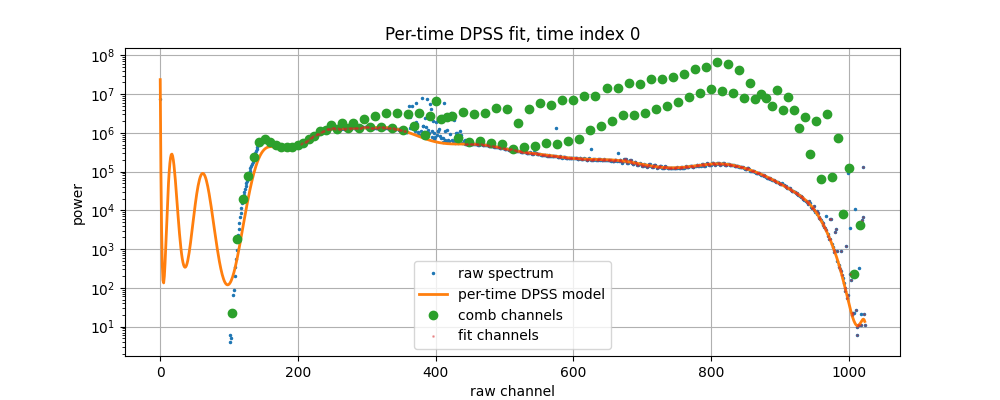

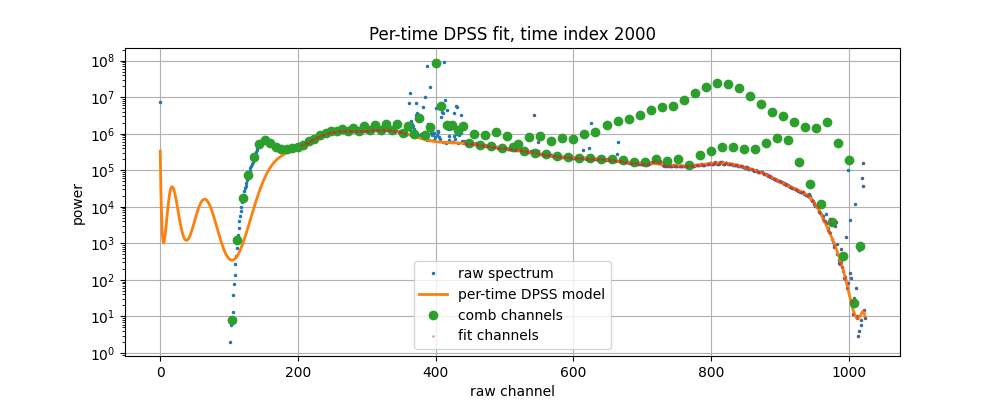

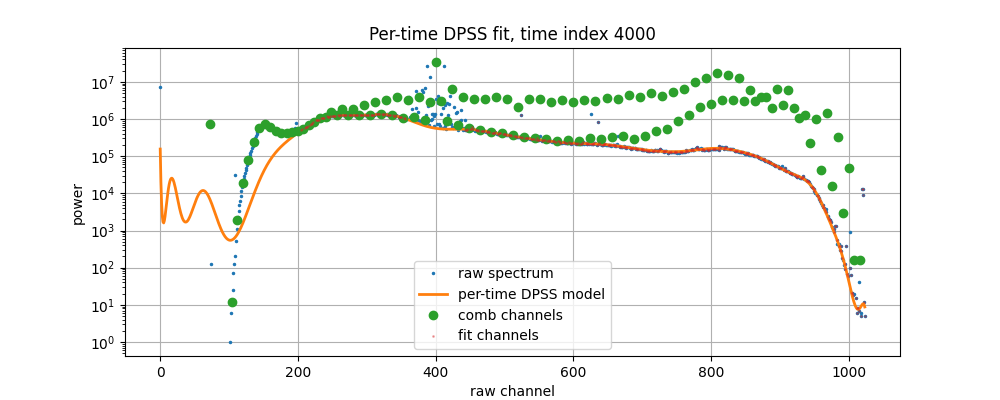

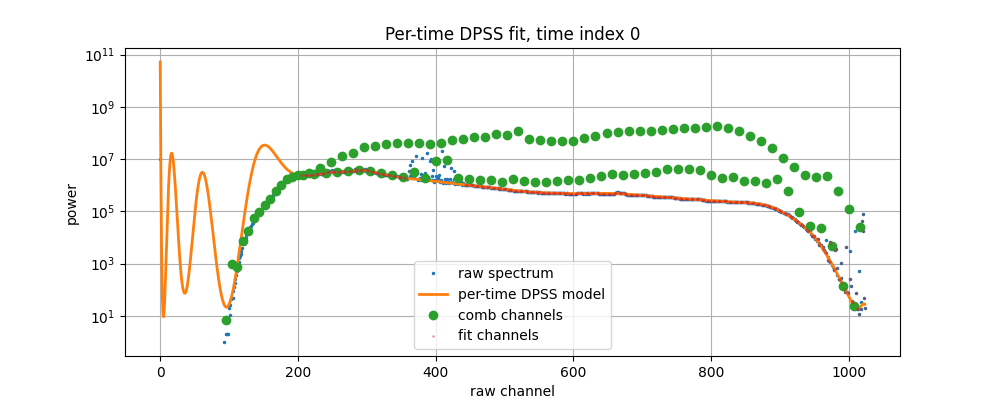

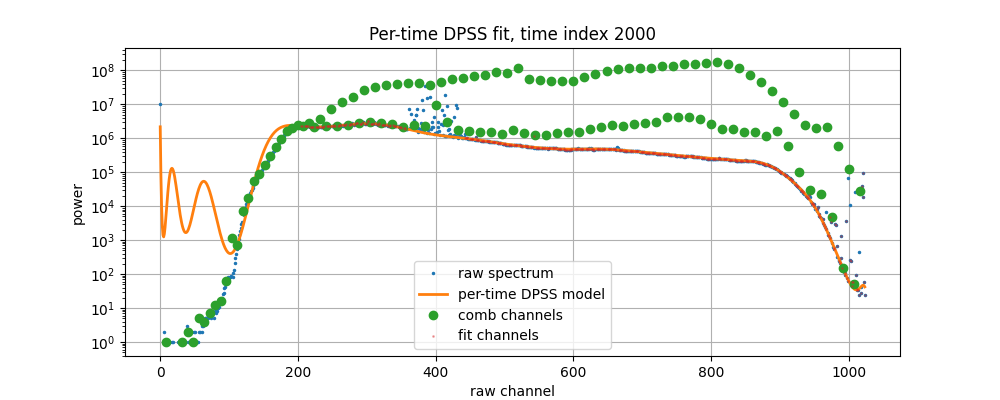

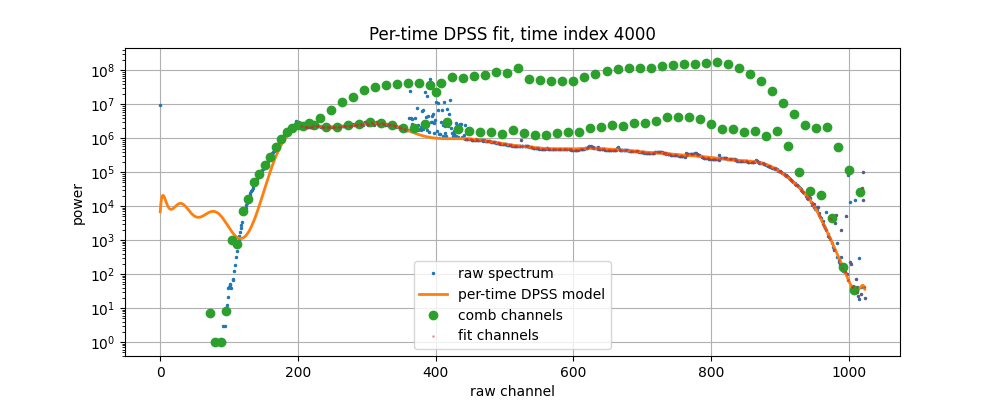

In [21]:
freqs = extracted['headers'][0]['header']['freqs']
chs_use = np.arange(8, 1024, 8)
sky = extracted['data']['4']
ground = extracted['data']['0']
cross = extracted['data']['04']
sky = sky[55+64:55+4939 + 1, :] ### Removed sweep to start scanning
ground = ground[55+64:55+4939 + 1, :] ### Removed sweep to start scanning
cross = cross[55+64:55+4939 + 1, :] ### Removed sweep to start scanning
reduced = sky[:,chs_use] - 0.5 * (sky[:,chs_use-1] + sky[:,chs_use+1])
# reduced = reduced[55:55+4939, :] # rot starts here and last unique pixel
test_data = reduced / np.mean(reduced, axis=0)

dpss_rot = fit_dpss_model_per_time(
    raw=sky,
    chs=chs_use,
    freqs=freqs,
    nw=4.0, #og
    # nw=8.0,
    nterms=32, # og
    # nterms=12, 
    include_poly=True,
    poly_order=2,
    guard_bins=1, #og
    # guard_bins=0,
    fit_min_chan=min(chs_use) - 8,
    fit_max_chan=sky.shape[1],
    use_log=True,
    ridge=1e-5, #og
    # ridge=1e-4,
    verbose=True,
)

dpss_ground = fit_dpss_model_per_time(
    raw=ground,
    chs=chs_use,
    freqs=freqs,
    nw=4.0, #og
    # nw=8.0,
    nterms=32, # og
    # nterms=12, 
    include_poly=True,
    poly_order=2,
    guard_bins=1, #og
    # guard_bins=0,
    fit_min_chan=min(chs_use) - 8,
    fit_max_chan=sky.shape[1],
    use_log=True,
    ridge=1e-5, #og
    # ridge=1e-4,
    verbose=True,
)

test_data_dpss = dpss_rot["test_data"]
rot_dpss = dpss_rot["reduced"]

summarize_dpss_reduction(
    dpss_out=dpss_rot,
    test_data_skyavg=test_data,
    rfi_bad=[0],
)

plot_dpss_fit_examples(
    raw=sky,
    dpss_out=dpss_rot,
    times_to_plot=(0, 2000, 4000),
    yscale="log",
)

plot_dpss_fit_examples(
    raw=ground,
    dpss_out=dpss_ground,
    times_to_plot=(0, 2000, 4000),
    yscale="log",
)

# plot_dpss_reduced_waterfalls(
#     dpss_out=dpss_rot,
#     test_data_skyavg=test_data,
#     rfi_bad=[0],
#     diff_lim=0.5,
# )

# plot_dpss_median_spectra(
#     dpss_out=dpss_rot,
#     test_data_skyavg=test_data,
#     rfi_bad=[0],
# )

In [22]:
els_list = []

for header_entry, metadata_entry in zip(
    extracted["headers"],
    extracted["metadata"],
):
    selected_indices = header_entry["selected_indices"]
    motor_data = metadata_entry["metadata"]["motor"]

    file_els = []

    for index in selected_indices:
        motor_entry = motor_data[index]

        if motor_entry is None:
            file_els.append(np.nan)
        else:
            file_els.append(
                motor_entry.get("el_pos", np.nan)
            )

    els_list.append(
        np.asarray(file_els, dtype=float)
    )


# Combine files and apply the same chronological sorting as the spectra.
# els = np.concatenate(els_list)[sort_index]
# els = np.concatenate(els_list)[sort_index][55:]
# els = np.concatenate(els_list)[sort_index][55:55+4939]
els = np.concatenate(els_list)[sort_index][55+64:55+4939+1] ### Removed going to start

extracted["el_pos"] = els

print("Elevation shape:", els.shape)
print("Number of missing elevations:", np.isnan(els).sum())
print("Number of spectra:", len(extracted["times"]))

azs_list = []

for header_entry, metadata_entry in zip(
    extracted["headers"],
    extracted["metadata"],
):
    selected_indices = header_entry["selected_indices"]
    motor_data = metadata_entry["metadata"]["motor"]

    file_azs = []

    for index in selected_indices:
        motor_entry = motor_data[index]

        if motor_entry is None:
            file_azs.append(np.nan)
        else:
            file_azs.append(
                motor_entry.get("az_pos", np.nan)
            )

    azs_list.append(
        np.asarray(file_azs, dtype=float)
    )


# Combine files and apply the same chronological sorting as the spectra.
# azs = np.concatenate(azs_list)[sort_index]
# azs = np.concatenate(azs_list)[sort_index][55:]
# azs = np.concatenate(azs_list)[sort_index][55:55+4939]
azs = np.concatenate(azs_list)[sort_index][55+64:55+4939+1 ] ### Removed going to sweep

extracted["az_pos"] = azs

print("Azimuth shape:", azs.shape)
print("Number of missing azimuths:", np.isnan(azs).sum())
print("Number of spectra:", len(extracted["times"]))

Elevation shape: (4876,)
Number of missing elevations: 0
Number of spectra: 6929
Azimuth shape: (4876,)
Number of missing azimuths: 0
Number of spectra: 6929


In [23]:
potmon_list = []
unsorted_times_list = []

for header_info, meta_info in zip(extracted['headers'], extracted['metadata']):
    indices = header_info['selected_indices']
    potmon = meta_info['metadata']['potmon']
    
    # Extract 'potmon' for the time-masked indices of this file
    file_potmon = np.array([potmon[idx]['pot_az_angle'] for idx in indices])
    potmon_list.append(file_potmon)
    
    # Track the unsorted times to re-derive the chronological sort order
    unsorted_times_list.append(header_info['header']['times'])

# Concatenate to match the script's pre-sorted state
unsorted_potmon = np.concatenate(potmon_list)
unsorted_times = np.concatenate(unsorted_times_list)

# Re-compute the exact same sort index used in your original script
sort_index = np.argsort(unsorted_times)

# Add the correctly shaped and sorted array back into your extracted dictionary
extracted['pot_az_angle'] = unsorted_potmon[sort_index]
az_step = extracted['az_pos'][55+64:55+4939 + 1] * (1.8 / 113)

In [24]:
el_deg_list = []
yaw_list = []
pitch_list = []
roll_list = []
accel_x_list = []
accel_y_list = []
accel_z_list = []
unsorted_times_list = []

for header_info, meta_info in zip(extracted['headers'], extracted['metadata']):
    indices = header_info['selected_indices']
    imu_el = meta_info['metadata']['imu_el']
    
    # Extract all parameters for the time-masked indices of this file
    el_deg_list.append(np.array([imu_el[idx]['el_deg'] for idx in indices]))
    yaw_list.append(np.array([imu_el[idx]['yaw'] for idx in indices]))
    pitch_list.append(np.array([imu_el[idx]['pitch'] for idx in indices]))
    roll_list.append(np.array([imu_el[idx]['roll'] for idx in indices]))
    accel_x_list.append(np.array([imu_el[idx]['accel_x'] for idx in indices]))
    accel_y_list.append(np.array([imu_el[idx]['accel_y'] for idx in indices]))
    accel_z_list.append(np.array([imu_el[idx]['accel_z'] for idx in indices]))
    
    # Track the unsorted times
    unsorted_times_list.append(header_info['header']['times'])

# Concatenate all lists to match the script's pre-sorted state
unsorted_el_deg = np.concatenate(el_deg_list)
unsorted_yaw = np.concatenate(yaw_list)
unsorted_pitch = np.concatenate(pitch_list)
unsorted_roll = np.concatenate(roll_list)
unsorted_accel_x = np.concatenate(accel_x_list)
unsorted_accel_y = np.concatenate(accel_y_list)
unsorted_accel_z = np.concatenate(accel_z_list)
unsorted_times = np.concatenate(unsorted_times_list)

# Re-compute the shared sort index based on timestamps
sort_index = np.argsort(unsorted_times)

# Add all correctly shaped and sorted arrays back into your extracted dictionary
extracted['el_deg'] = unsorted_el_deg[sort_index]
extracted['yaw'] = unsorted_yaw[sort_index]
extracted['pitch'] = unsorted_pitch[sort_index]
extracted['roll'] = unsorted_roll[sort_index]
extracted['accel_x'] = unsorted_accel_x[sort_index]
extracted['accel_y'] = unsorted_accel_y[sort_index]
extracted['accel_z'] = unsorted_accel_z[sort_index]
extracted['times'] = unsorted_times[sort_index]

In [25]:
accel_matrix = np.column_stack([
    np.array(extracted['accel_x']),
    np.array(extracted['accel_y']),
    np.array(extracted['accel_z'])
])

# 2. Use Singular Value Decomposition (SVD) to find the plane of rotation.
# This mathematically isolates the 2D plane the sensor sweeps through, 
# completely ignoring arbitrary mounting skews or orientation offsets.
U, S, Vt = np.linalg.svd(accel_matrix, full_matrices=False)

# Vt[0] and Vt[1] are the two orthogonal vectors spanning the rotation plane.
u = Vt[0, :]  # Plane X-axis
v = Vt[1, :]  # Plane Y-axis

# 3. Project every 3D acceleration sample onto these two plane axes
proj_x = np.dot(accel_matrix, u)
proj_y = np.dot(accel_matrix, v)

# 4. Compute the true angle across the full circle using arctan2
raw_angle = np.unwrap(np.degrees(np.arctan2(proj_y, proj_x)), period=360) - 180


In [26]:
el_step = els / (113/1.8)
az_step = azs / (113/1.8)
# Usage:
az_pot = np.copy(extracted['pot_az_angle'][55+64:55+4939 + 1])
az_pot = extract_clean_pot_data_v2(az_pot, az_step)

el_imu = raw_angle[55+64:55+4939 + 1]

In [27]:
### Choose which mapping to use
az_deg = az_pot.copy()
el_deg = el_imu.copy()

# az_deg = az_step.copy()
# el_deg = el_step.copy()

In [28]:
chs = np.arange(8, 1024, 8)
# dpss_red = dpss_rot['reduced'].copy()
dpss_red = rot_dpss.copy()
ground_dpss = dpss_ground["reduced"]
dpss_red_norm = np.mean(dpss_red, axis=0)
ground_dpss_norm = np.mean(ground_dpss, axis=0)

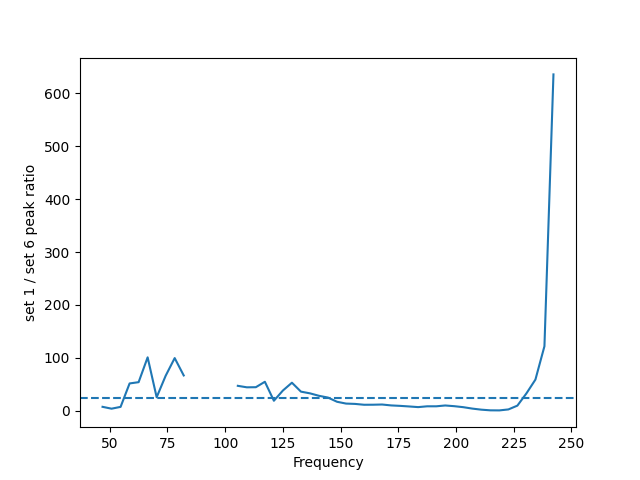

In [29]:
scale_factors, peak_powers = calibrate_weak_arm(el_deg, az_deg, dpss_red)

dpss_red_corrected = dpss_red.copy()

dpss_red_corrected[:, 1::2] *= scale_factors

plt.figure()
# plt.plot(freqs[::8][::2][:-1], ratio)
plt.plot(freqs[::8][::2][:-1], scale_factors)
# plt.plot(freqs[::8][::2][:-1], dpss_red)
plt.axhline(25, linestyle="--")
plt.ylabel("set 1 / set 6 peak ratio")
plt.xlabel("Frequency")
plt.show()

In [30]:
shift_new = 27
rot_masked = dpss_red_corrected.copy()
rot_masked = rot_masked[:, shift_new:]
rot_1 = rot_masked[:, ::2]
rot_6 = rot_masked[:, 1::2]

freqs_1 = freqs[::8][shift_new:][::2][30:40]
freqs_6 = freqs[::8][shift_new:][1::2][30:40]
rot_1_cut = rot_1[:, 30:40].copy()
rot_6_cut = rot_6[:, 30:40].copy()
dpss_red_masked = dpss_red_corrected.copy()
dpss_red_masked = dpss_red_masked[:, shift_new:]
dpss_red_ground = ground_dpss[:, shift_new:]

In [31]:
P_meas = np.copy(dpss_red_masked)
rfi_mask, baseline, residual = flag_rfi_time(
    P_meas,
    window=21,
    sigma=16.0,
    floor_fraction=0.1,
)

rfi_mask_expanded = binary_dilation(
    rfi_mask,
    structure=np.ones((3, 1), dtype=bool),
)

P_clean = P_meas.copy()
P_clean[rfi_mask_expanded] = baseline[rfi_mask_expanded]

# P_clean = P_meas.copy()

# P_clean[rfi_mask] = baseline[rfi_mask]

Px_hat, Py_hat, G_hat, bad_time, rfi_occupancy = (
    fit_dpss_interleaved_fix(
        # P_meas,
        P_clean,
        freqs[::8][shift_new:-1],
        # rfi_mask=rfi_mask,
        # nmodes=4,
        nmodes=23,
        NW=4.0,
        # max_bad_fraction=0.35,
    )
)

## Modeling and Best Fit Extraction

In [32]:
# Found in new_data_gemini notebook, slighlt different from below, gotta jointly fit i think, takes too long to run tho
best_alpha_joint = 41.901193371656355

51.0


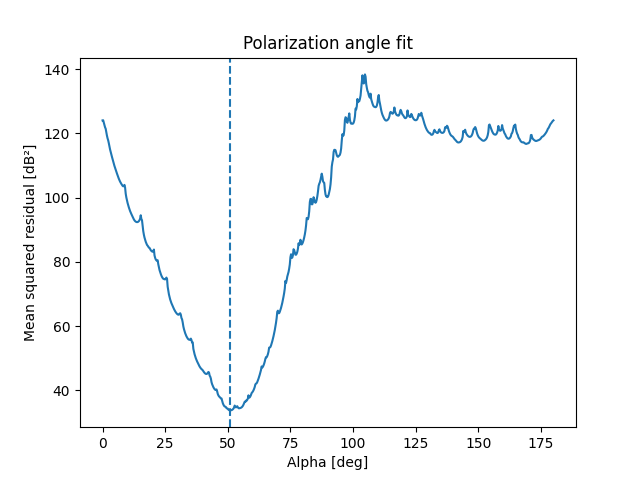

In [50]:
alphas, losses, best_alpha_scan = scan_alpha(
    rot_6_cut[:, 2],
    # rot_1_cut[:, 2],
    bowtie_beams_use[34],
    az_deg,
    # az_clean,
    el_deg,
)

print(best_alpha_scan)
best_alpha_joint = best_alpha_scan.copy() ### Checking if its the same

plt.figure()
plt.plot(alphas, losses)
plt.axvline(best_alpha_scan, linestyle="--")
plt.xlabel("Alpha [deg]")
plt.ylabel("Mean squared residual [dB²]")
plt.title("Polarization angle fit")
plt.show()

In [33]:

freq_idx = 40  # Keep it as a list so it remains 2D
data_indices = (freq_idx * 2) + 1
data_1freq = Py_hat[:, data_indices]
# data_1freq = Px_hat[:, data_indices]
beam_1freq = bowtie_beams_use[freq_idx]

# Normalize
data_1freq = data_1freq / np.mean(data_1freq, axis=0)

# 2. Decimate the time/rotation axis by a factor of 10
stride = 10
data_fast = data_1freq[::stride]
az_fast = az_deg[::stride]
el_fast = el_deg[::stride]

# Run the fit with a coarser grid
res, best_coord, best_theta, best_phi, loss_2d, extent = fit_coord_multifreq_fixed_alpha(
    data=data_fast,
    rx_beams=beam_1freq,
    az_deg=az_fast,
    el_deg=el_fast,
    fixed_alpha=best_alpha_joint, 
    # fixed_alpha=best_alpha_joint-90, 
    grid_res=10.0,  # 3. 10-degree grid (Nelder-Mead will still refine this to 1e-7 precision)
)

Executing JAX 2D grid search across 19x37 configurations...


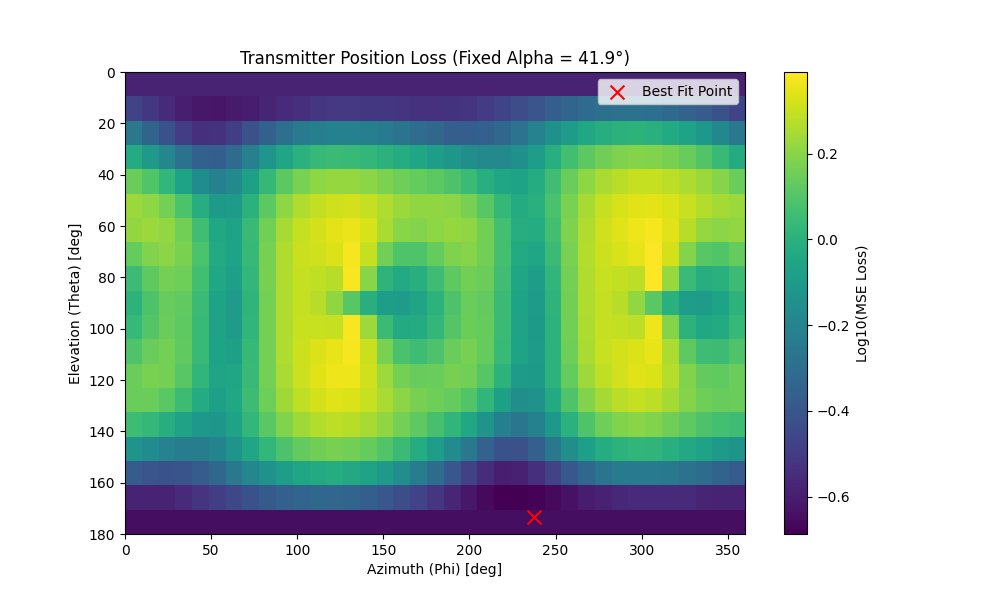

In [34]:
plt.figure(figsize=(10, 6))

im = plt.imshow(
    np.log10(loss_2d), 
    extent=extent, 
    aspect='auto', 
    cmap='viridis'
)
plt.colorbar(im, label='Log10(MSE Loss)')

plt.scatter(best_phi, best_theta, color='red', marker='x', s=100, label='Best Fit Point')

plt.title(f"Transmitter Position Loss (Fixed Alpha = {best_alpha_joint:.1f}°)")
plt.xlabel("Azimuth (Phi) [deg]")
plt.ylabel("Elevation (Theta) [deg]")
plt.legend()
plt.show()

Executing JAX grid search across 46x181 points...


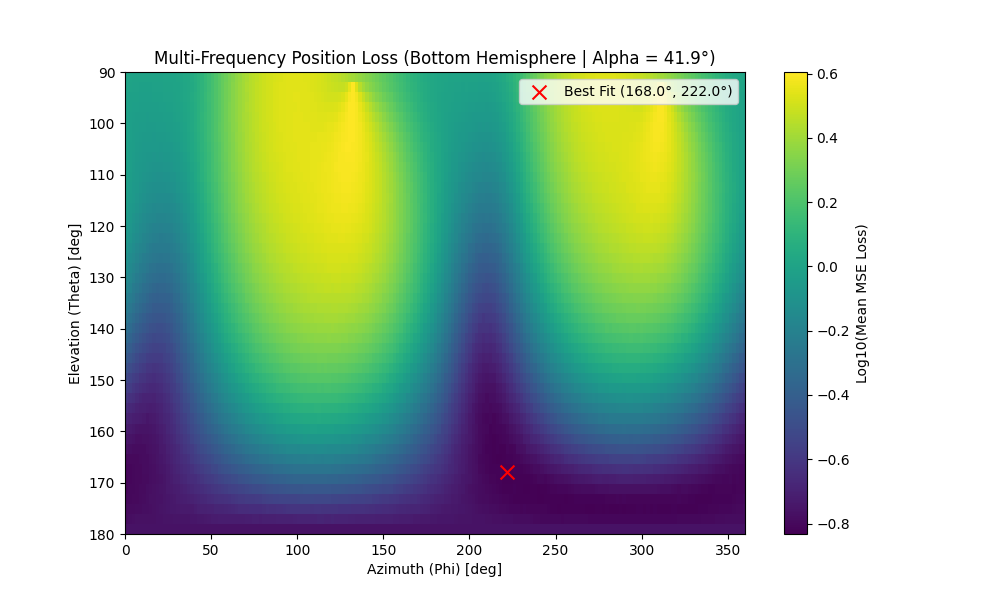

In [35]:
hfss_indices = [25, 27, 29, 31, 33]  # Make sure these are valid indices in bowtie_beams_use

# 2. Map them to the correct interleaved data indices (assuming Py_hat / odd comb)
data_indices = [(idx * 2) + 1 for idx in hfss_indices]

# Extract the multi-frequency subsets
data_use = Py_hat[:, data_indices]          # Shape: (n_samples, n_freqs)
beams_use = bowtie_beams_use[hfss_indices]  # Shape: (n_freqs, 3, n_pix)

# 3. Normalize each frequency independently so high-power channels don't dominate
data_use = data_use / np.mean(data_use, axis=0)

# 4. Decimate the time/rotation axis for speed
stride = 10
data_fast = data_use[::stride]
az_fast = az_deg[::stride]
el_fast = el_deg[::stride]

# 5. Run the multi-frequency grid search
res, best_coord, best_theta, best_phi, loss_2d, extent = fit_coord_multifreq_fixed_alpha_fast(
    data=data_fast,
    rx_beams_array=beams_use,
    az_deg=az_fast,
    el_deg=el_fast,
    fixed_alpha=best_alpha_joint, 
    theta_bounds=(90.0, 180.0), 
    grid_res=2.0, 
)

# --- PLOT THE MULTI-FREQUENCY LANDSCAPE ---
plt.figure(figsize=(10, 6))
im = plt.imshow(
    np.log10(loss_2d), 
    extent=extent, 
    aspect='auto', 
    cmap='viridis'
)
plt.colorbar(im, label='Log10(Mean MSE Loss)')
plt.scatter(best_phi, best_theta, color='red', marker='x', s=100, label=f'Best Fit ({best_theta:.1f}°, {best_phi:.1f}°)')
plt.title(f"Multi-Frequency Position Loss (Bottom Hemisphere | Alpha = {best_alpha_joint:.1f}°)")
plt.xlabel("Azimuth (Phi) [deg]")
plt.ylabel("Elevation (Theta) [deg]")
plt.legend()
plt.show()

Executing JAX X-Y grid search across 51x51 points...
Best Cartesian Coord [x, y, z]: [ 0.00290943 -0.0780042  -0.99694878]


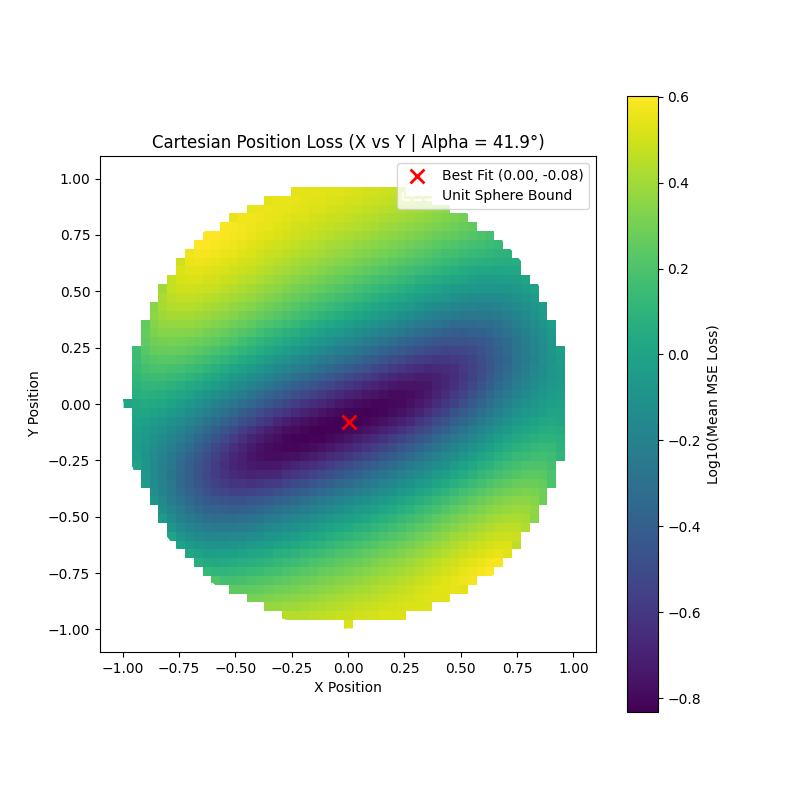

In [36]:
hfss_indices = [25, 27, 29, 31, 33]  # Make sure these are valid indices in bowtie_beams_use
data_indices = [(idx * 2) + 1 for idx in hfss_indices]

data_use = Py_hat[:, data_indices]          
beams_use = bowtie_beams_use[hfss_indices]  

# Normalize
data_use = data_use / np.mean(data_use, axis=0)

# Decimate time axis
stride = 10
data_fast = data_use[::stride]
az_fast = az_deg[::stride]
el_fast = el_deg[::stride]

# 2. Run the X-Y fit
res, best_coord, best_x, best_y, loss_2d, extent = fit_coord_xy_fixed_alpha_fast(
    data=data_fast,
    rx_beams_array=beams_use,
    az_deg=az_fast,
    el_deg=el_fast,
    fixed_alpha=best_alpha_joint, 
    xy_bounds=(-1.0, 1.0), 
    grid_res=0.04,  # Fine grid resolution for x and y
)

print("Best Cartesian Coord [x, y, z]:", best_coord)

# --- PLOT THE X-Y LANDSCAPE ---
plt.figure(figsize=(8, 8))

# Note the .T and origin='lower' to match standard Cartesian axes (X horizontal, Y vertical)
im = plt.imshow(
    np.log10(loss_2d).T, 
    # (loss_2d).T, 
    extent=extent, 
    origin='lower',
    aspect='equal', 
    cmap='viridis'
)
plt.colorbar(im, label='Log10(Mean MSE Loss)')

# Overlay the best fit point
plt.scatter(best_x, best_y, color='red', marker='x', s=100, linewidth=2, label=f'Best Fit ({best_x:.2f}, {best_y:.2f})')

# Draw the unit circle boundary ($x^2 + y^2 = 1$) for reference
circle = plt.Circle((0, 0), 1.0, color='white', fill=False, linestyle='--', linewidth=1.5, label='Unit Sphere Bound')
plt.gca().add_patch(circle)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.title(f"Cartesian Position Loss (X vs Y | Alpha = {best_alpha_joint:.1f}°)")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend(loc='upper right')
plt.show()

In [37]:
sim_all_freqs_raw, pxs_all_freqs_raw = simulate_both_arms_interleaved(
    bowtie_beams_use=bowtie_beams_use,
    az_deg=az_deg,
    el_deg=el_deg,
    coord=best_coord,
    alpha=best_alpha_joint-90,
)

# Transpose so shape is (n_measurements, n_frequencies) matching your experimental data
sim_all_freqs_raw = sim_all_freqs_raw.T

## Beam Mapping

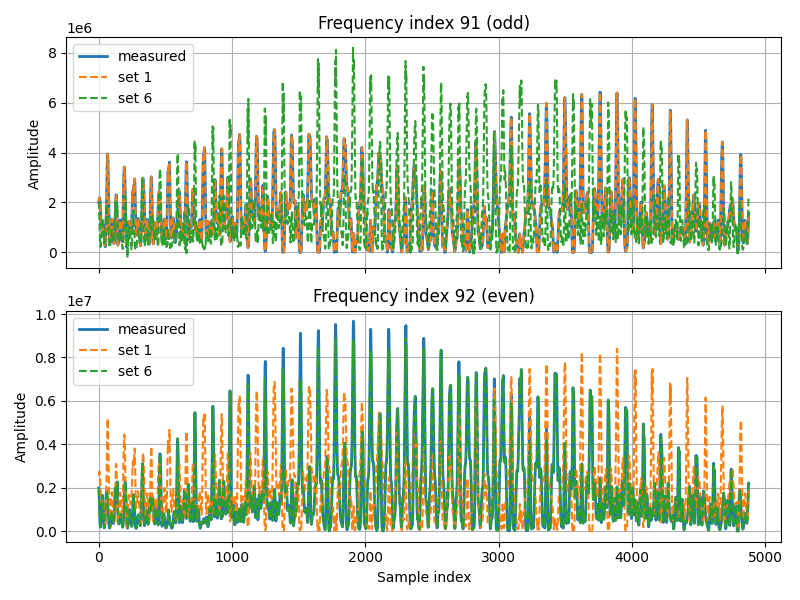

In [38]:
freq_indices = [91, 92]

fig, axes = plt.subplots(
    len(freq_indices),
    1,
    figsize=(8, 6),
    sharex=True,
)

for ax, fi in zip(axes, freq_indices):

    ax.plot(
        P_meas[:, fi],
        label="measured",
        linewidth=2,
    )

    ax.plot(
        Py_hat[:, fi],
        "--",
        label="set 1",
    )

    ax.plot(
        Px_hat[:, fi],
        "--",
        label="set 6",
    )

    ax.set_ylabel("Amplitude")
    ax.set_title(
        f"Frequency index {fi} "
        f"({'even' if fi % 2 == 0 else 'odd'})"
    )

    ax.grid()
    ax.legend()

axes[-1].set_xlabel("Sample index")

plt.tight_layout()

In [43]:
lmax=5

### USing best coord pixles
# ind = 71
# ind_hfss = 37
# ind = 91
# ind_hfss = 47
ind = 65
ind_hfss = 34
# ind = 29
# ind_hfss = 16
# ind = 31
# ind_hfss = 17
# ind = 33
# ind_hfss = 18
empty_map = np.full_like(
    bowtie_beams_use[0, 0],
    fill_value=hp.UNSEEN,
    dtype=float,
)
valid = (
    # ~flagged
    ~rfi_mask[:, ind]
    # & np.isfinite(Px_hat[:, ind])
    & np.isfinite(Py_hat[:, ind]+Px_hat[:, ind])
    # & (pxs_all_freqs_raw >= 0)
    # & (pxs_all_freqs_raw < empty_map.size)
    # & (pxs_all_freqs_raw[ind] >= 0)
    # & (pxs_all_freqs_raw[ind] < empty_map.size)
    # & (Px_hat[:, ind] > 0) ### Just added
)
empty_map[pxs_all_freqs_raw[ind][valid]] = G_hat[valid, ind]
# empty_map[pxs_all_freqs_raw[ind]] = G_hat[:, ind]
# empty_map[pxs_all_freqs_raw[valid]] = G_hat[valid, ind] / np.max(G_hat[valid, ind])
gain_maps = np.sum(np.abs(bowtie_beams_use)**2, axis=1)
gain_maps = gain_maps / np.max(gain_maps, axis=1, keepdims=True)

unseen_rec = np.full_like(empty_map, fill_value=hp.UNSEEN)
unseen_rec[pxs_all_freqs_raw[ind]] = gain_maps[ind_hfss][pxs_all_freqs_raw[ind]] 
# rec_truth = sph_fit(unseen_rec, lmax=16, lam=lam)
rec_truth = sph_fit(unseen_rec, lmax=lmax, lam=lam)
vmin = np.min(rec_truth[0]/np.max(rec_truth[0]))
vmax = np.max(rec_truth[0]/np.max(rec_truth[0]))


In [44]:
# gain_maps_sph = beam_maps_ph + beam_maps_th
# gain_maps_sph = gain_maps_sph / np.max(gain_maps_sph, axis=1, keepdims=True)
# gain_maps.shape, gain_maps_sph.shape

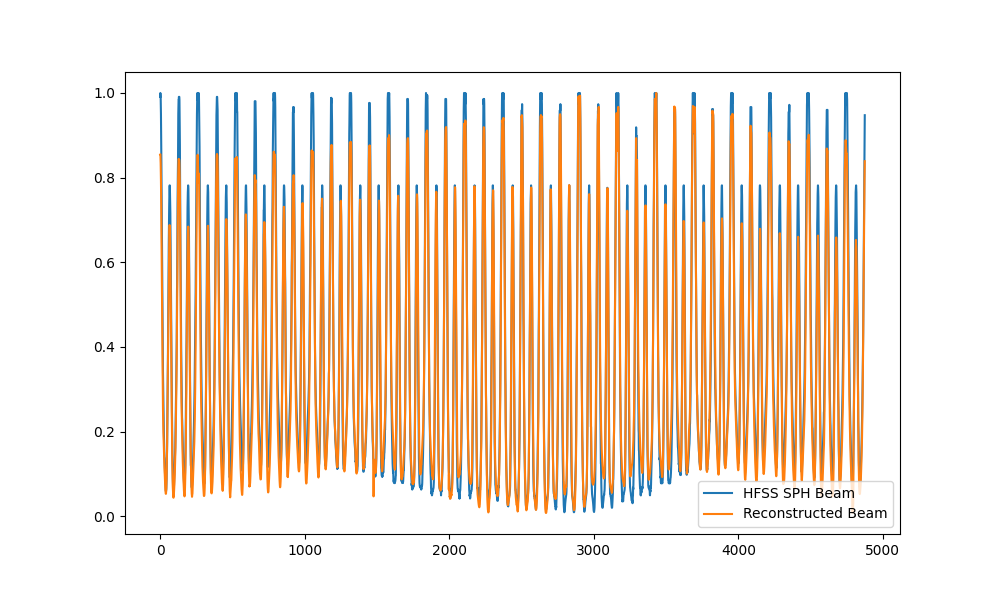

In [45]:
plt.figure(figsize=(10, 6))
# plt.plot(gain_maps[ind, pxs[valid]], label='HFSS CART Beam')
plt.plot(gain_maps_sph[ind_hfss, pxs_all_freqs_raw[ind][valid]], label='HFSS SPH Beam')
plt.plot(G_hat[valid, ind] / np.max(G_hat[valid, ind]), label='Reconstructed Beam')
plt.legend()
plt.show()

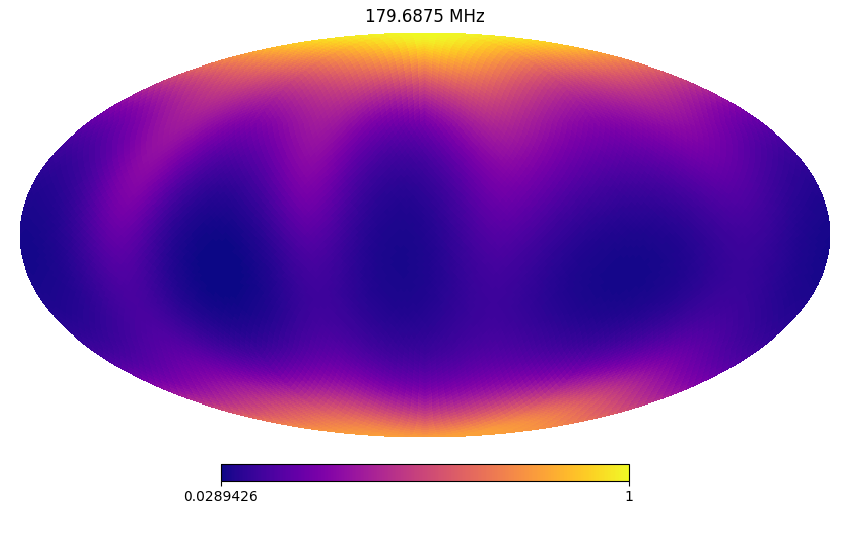

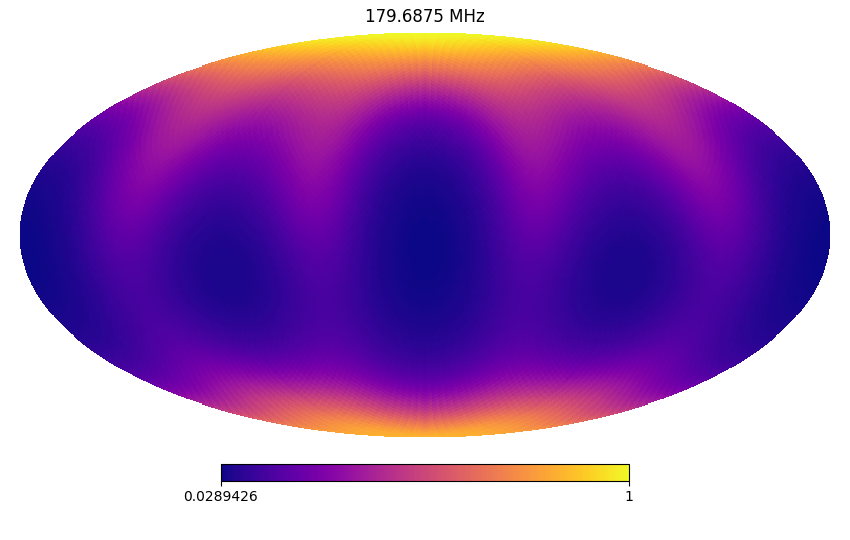

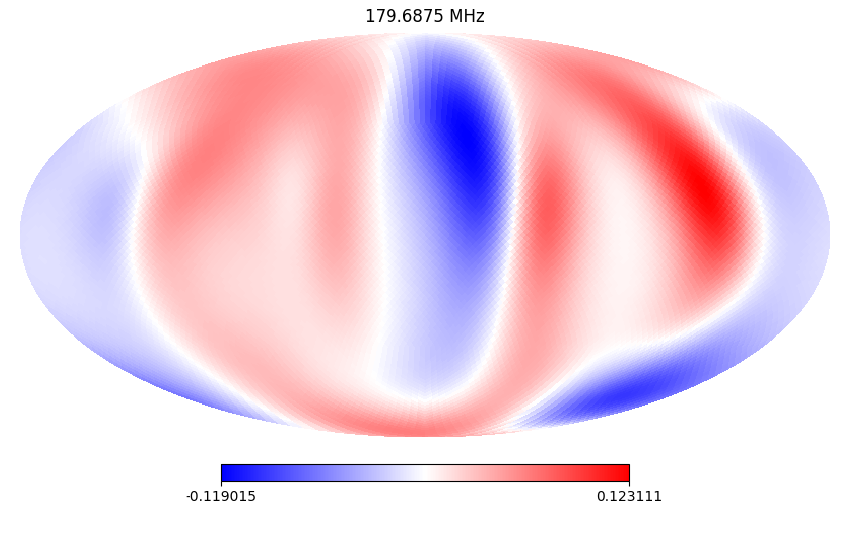

In [46]:
# rec_maps = sph_fit(empty_map, lmax=5, lam=lam)
rec_maps = sph_fit(empty_map, lmax=lmax, lam=lam)
# vmin = np.min(rec_truth[0])
# vmax = np.max(rec_truth[0])
hp.mollview(rec_maps[0]/np.max(rec_maps[0]), cmap='plasma', title=f'{freqs[::8][27:-1][ind]} MHz', min=vmin, max=vmax)
hp.mollview(rec_truth[0]/np.max(rec_truth[0]), cmap='plasma', title=f'{freqs[::8][27:-1][ind]} MHz', min=vmin, max=vmax)
hp.mollview(rec_truth[0]/np.max(rec_truth[0]) - rec_maps[0]/np.max(rec_maps[0]), cmap='bwr', title=f'{freqs[::8][27:-1][ind]} MHz')

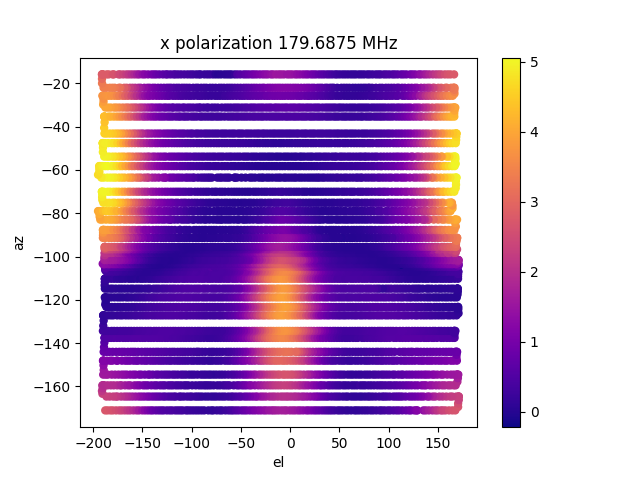

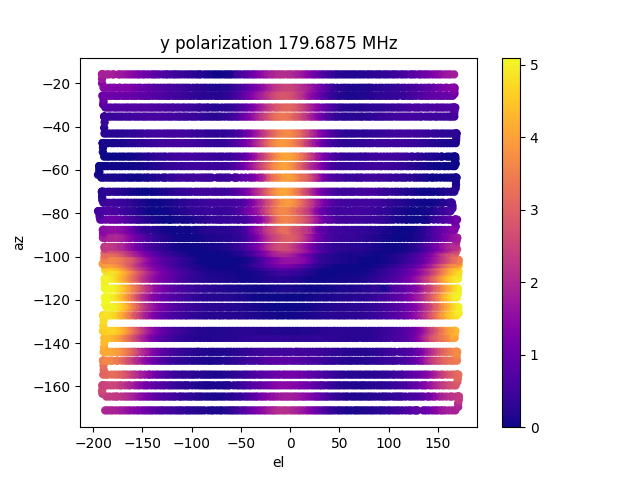

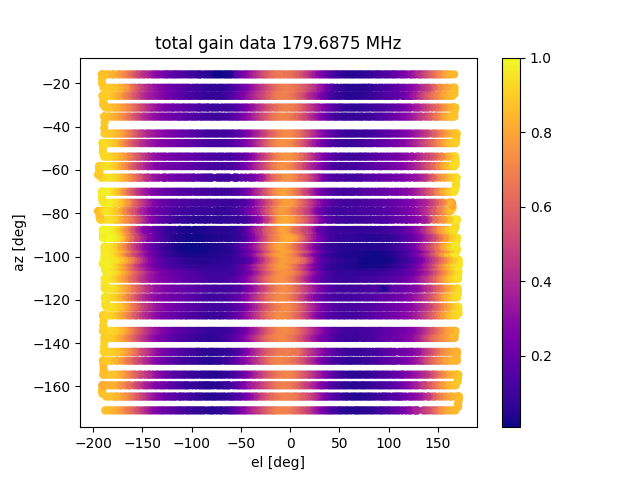

In [47]:

Px_mean = (Px_hat[:, ind]/np.mean(Px_hat[:, ind]))
Py_mean = (Py_hat[:, ind]/np.mean(Py_hat[:, ind]))
# dpss_gain = (Py_hat[:, ind]/np.mean(Py_hat[:, ind])) + (Px_hat[:, ind]/np.mean(Px_hat[:, ind]))
dpss_gain = Px_mean + Py_mean
# dpss_gain = (Py_hat[:, ind]/np.max(Py_hat[:, ind])) + (Px_hat[:, ind]/np.max(Px_hat[:, ind]))
dpss_norm = dpss_gain / np.max(dpss_gain)
plt.figure()
plt.scatter(el_deg, az_deg, c=Px_mean, s=25, cmap='plasma')
plt.colorbar()
plt.xlabel('el')
plt.ylabel('az')
plt.title(f'x polarization {freqs[::8][27:-1][ind]} MHz')
plt.show()

plt.figure()
plt.scatter(el_deg, az_deg, c=Py_mean, s=25, cmap='plasma')
plt.colorbar()
plt.xlabel('el')
plt.ylabel('az')
plt.title(f'y polarization {freqs[::8][27:-1][ind]} MHz')
plt.show()

plt.figure()
plt.scatter(el_deg, az_deg, c=dpss_norm, s=25, cmap='plasma')
plt.colorbar()
plt.xlabel('el [deg]')
plt.ylabel('az [deg]')
plt.title(f'total gain data {freqs[::8][27:-1][ind]} MHz')
plt.show()

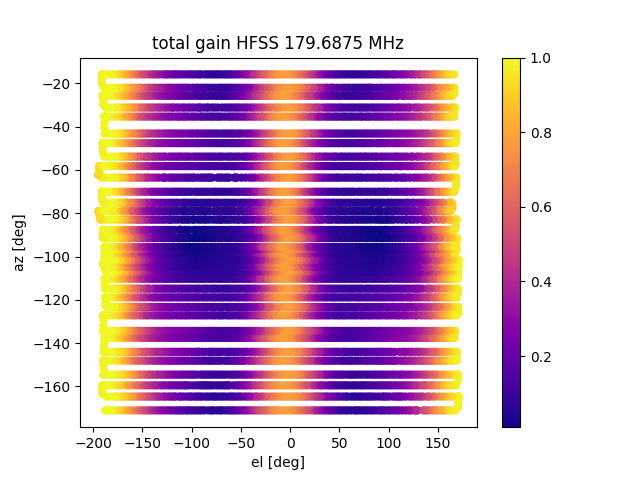

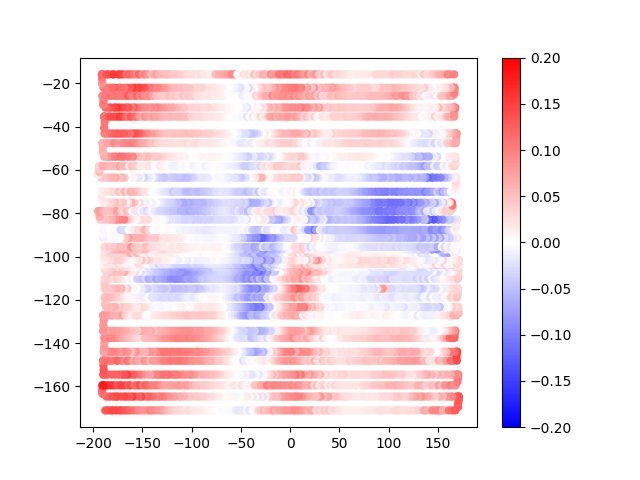

In [48]:
test_hfss = gain_maps_sph[ind_hfss, pxs_all_freqs_raw[ind]]
plt.figure()
plt.scatter(el_deg, az_deg, c=test_hfss, s=25, cmap='plasma')
plt.colorbar()
plt.title(f'total gain HFSS {freqs[::8][27:-1][ind]} MHz')
plt.xlabel('el [deg]')
plt.ylabel('az [deg]')
plt.show()

plt.figure()
plt.scatter(el_deg, az_deg, c=(test_hfss - dpss_norm), s=25, cmap='bwr', 
           vmin=-.2, vmax=.2)
plt.colorbar()
plt.show()

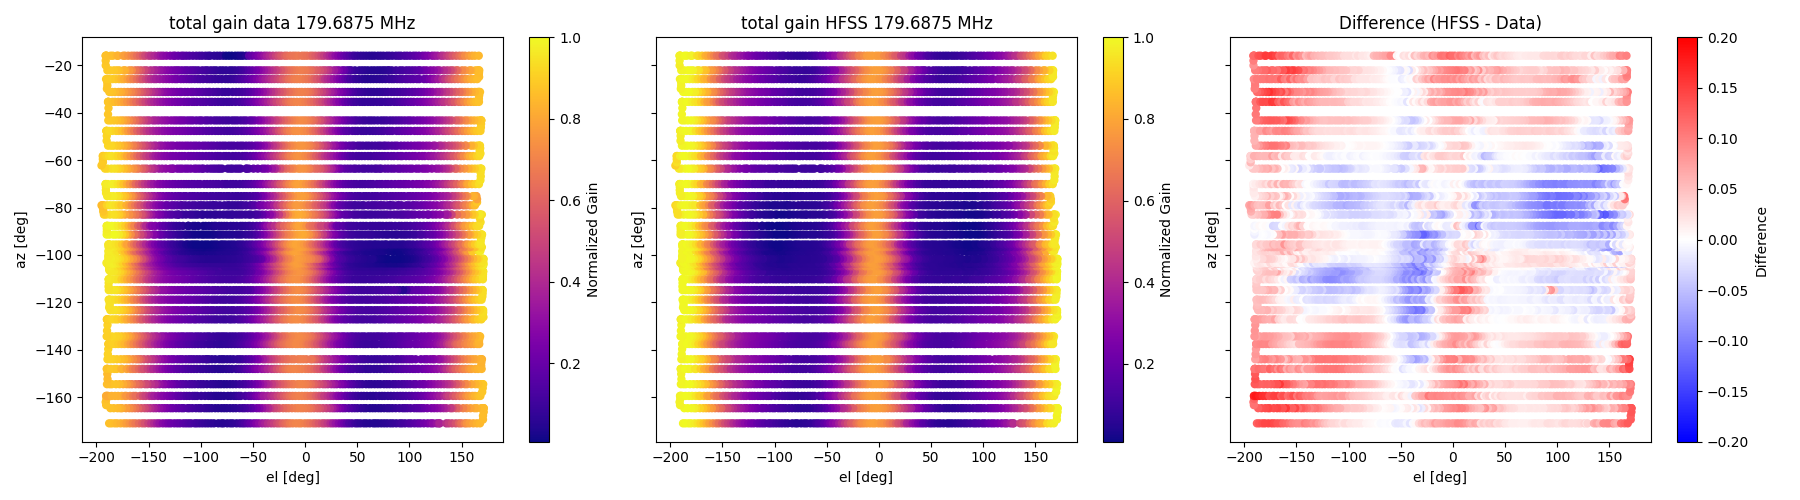

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 1x3 subplot layout sharing x and y axes
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# 1. Total gain data (DPSS)
sc1 = axes[0].scatter(el_deg, az_deg, c=dpss_norm, s=25, cmap='plasma')
axes[0].set_xlabel('el [deg]')
axes[0].set_ylabel('az [deg]')
axes[0].set_title(f'total gain data {freqs[::8][27:-1][ind]} MHz')
cbar1 = fig.colorbar(sc1, ax=axes[0])
cbar1.set_label('Normalized Gain')

# 2. Total gain HFSS
sc2 = axes[1].scatter(el_deg, az_deg, c=test_hfss, s=25, cmap='plasma')
axes[1].set_xlabel('el [deg]')
axes[1].set_ylabel('az [deg]')
axes[1].set_title(f'total gain HFSS {freqs[::8][27:-1][ind]} MHz')
cbar2 = fig.colorbar(sc2, ax=axes[1])
cbar2.set_label('Normalized Gain')

# 3. Difference (HFSS - DPSS)
sc3 = axes[2].scatter(
    el_deg,
    az_deg,
    c=(test_hfss - dpss_norm),
    s=25,
    cmap='bwr',
    vmin=-0.2,
    vmax=0.2,
)
axes[2].set_xlabel('el [deg]')
axes[2].set_ylabel('az [deg]')
axes[2].set_title('Difference (HFSS - Data)')
cbar3 = fig.colorbar(sc3, ax=axes[2])
cbar3.set_label('Difference')

plt.tight_layout()
plt.show()

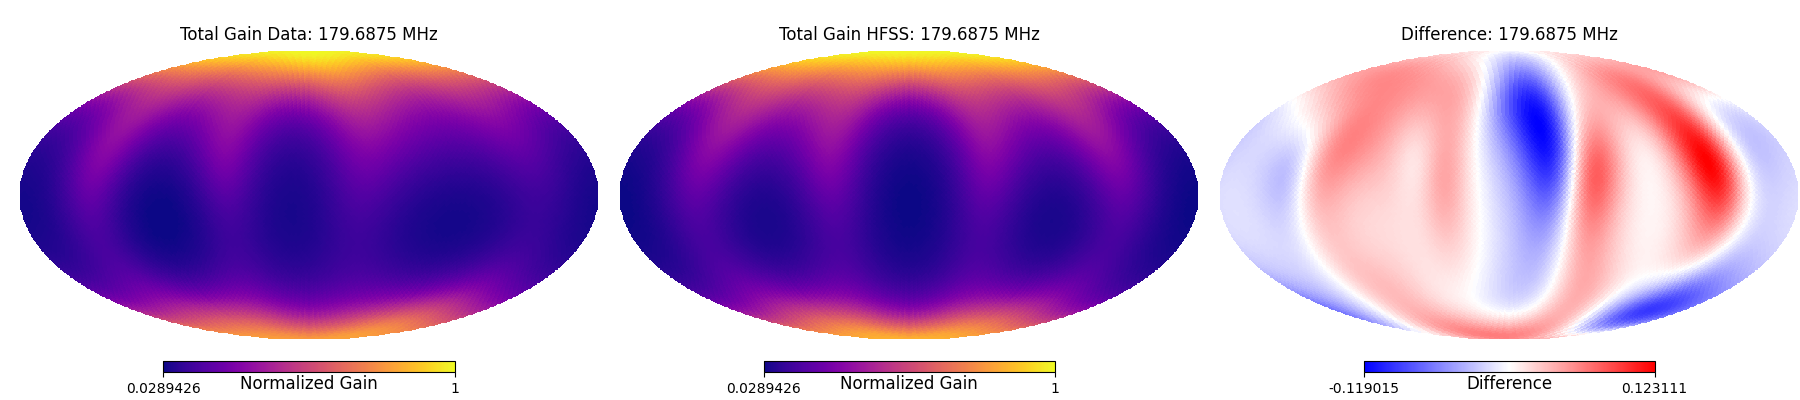

In [50]:

# Create a single figure canvas
plt.figure(figsize=(18, 4))

# 1. First map (rec_maps)
hp.mollview(
    rec_maps[0] / np.max(rec_maps[0]),
    cmap='plasma',
    title=f'Total Gain Data: {freqs[::8][27:-1][ind]} MHz',
    min=vmin,
    max=vmax,
    unit='Normalized Gain',
    sub=(1, 3, 1),
)

# 2. Second map (rec_truth)
hp.mollview(
    rec_truth[0] / np.max(rec_truth[0]),
    cmap='plasma',
    title=f'Total Gain HFSS: {freqs[::8][27:-1][ind]} MHz',
    min=vmin,
    max=vmax,
    unit='Normalized Gain',
    sub=(1, 3, 2),
)

# 3. Third map (Difference)
hp.mollview(
    (rec_truth[0] / np.max(rec_truth[0]))
    - (rec_maps[0] / np.max(rec_maps[0])),
    cmap='bwr',
    title=f'Difference: {freqs[::8][27:-1][ind]} MHz',
    unit='Difference',
    sub=(1, 3, 3),
)

plt.show()